In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
import json
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# Tomographic Reconstruction of Basketball Movement Data - Pacers @ Raptors, October 28th, 2015

In this case study, we will be using SportsVU movement data alongside play by play data to construct meaningful visualizations of The Toronto Raptors offense. The analysis below details the data cleaning, preprocessing, visualization and machine learning used to produce spatial reconstruction using ball movement data. The end goal is to reconstruct offensive threat given the ball's position on the court using naive models (conditional probability, movement heatmaps) and interpretable machine learning models outlined in a study conducted by Jairo Diaz-Rodriguez and his peers. This notebook aims to be an extension of the methods used in the study (link below).

Code and analysis completed by Jonathan Channer under the supervision of Dr. Jairo Diaz-Rodriguez.

Play by play data: [Kaggle](https://www.kaggle.com/datasets/brains14482/nba-playbyplay-and-shotdetails-data-19962021?select=nbastats_2015.csv)  
Play by play parsing: [Ryan Davis](https://github.com/rd11490/NBA_Tutorials/tree/master/play_by_play_parser)   
SportsVU game logs: [Kostya Linou](https://github.com/linouk23/NBA-Player-Movements/tree/master)  
Tomographic reconstruction of a disease transmission landscape via GPS recorded random paths: [Article](https://arxiv.org/pdf/2404.04455)

## Reading the Data

The play-by-play parser provides possession segments for both teams. Inspection of this game showed that the parser's `possession_start` is not a reliable movement boundary: for many rows it is equal to that row's end time. The corrected interval therefore starts at the preceding **game segment's** end, applied before filtering to Toronto. The raw parser times and original game-row number are retained for auditability.

`SOURCE_POSSESSION_NUMBER` is assigned once from Toronto's source order and is never renumbered. After converting the game-elapsed values to quarter-clock values, any interval whose start equals its end is retained in possession metadata and point totals but flagged as `zero_duration`. These stopped-clock records can represent valid play-by-play segments, including free throws; this notebook does not infer their cause or merge them automatically. Because a zero-length interval cannot support a movement path, it is also flagged `movement_eligible = False` and excluded from spatial models without fabricating a duration or borrowing a nearby tracking frame.

In [2]:
df = pd.read_csv("Data/0021500009_possessions.csv")

In [3]:
df

,team1_id,team1_player1,team1_player2,team1_player3,team1_player4,team1_player5,team2_id,team2_player1,team2_player2,team2_player3,team2_player4,team2_player5,game_id,period,possession_start,possession_end,team1_points,team2_points,possession_team
0,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,201960,202685,21500009,1,0,17,0,2,1610612761
1,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,201960,202685,21500009,1,32,33,0,0,1610612754
2,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,201960,202685,21500009,1,38,38,0,0,1610612761
3,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,201960,202685,21500009,1,50,50,2,0,1610612754
4,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,201960,202685,21500009,1,75,75,0,2,1610612761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1610612754,101139,101145,201588,201941,202331,1610612761,200768,201942,201960,202685,202709,21500009,4,2853,2861,0,0,1610612754
201,1610612754,101139,101145,201588,201941,202331,1610612761,200768,201942,201960,202685,202709,21500009,4,2862,2862,0,2,1610612761
202,1610612754,101139,101145,201588,201941,202331,1610612761,200768,201942,201960,202685,202709,21500009,4,2866,2867,2,0,1610612754
203,1610612754,101139,201588,201941,202331,202730,1610612761,200768,201942,201960,202685,202709,21500009,4,2868,2868,0,1,1610612761


In [4]:
# Preserve the parser values before correcting interval starts.
df = df.copy()
df["source_row_number"] = np.arange(1, len(df) + 1)
df["parser_possession_start"] = df["possession_start"]
df["parser_possession_end"] = df["possession_end"]

# The usable start is the preceding game segment's end. Do this before team filtering.
df["possession_start"] = df["parser_possession_end"].shift(1)
first_segment_mask = df["possession_start"].isna()
df.loc[first_segment_mask, "possession_start"] = df.loc[
    first_segment_mask, "parser_possession_start"
]
df.head()

,team1_id,team1_player1,team1_player2,team1_player3,team1_player4,team1_player5,team2_id,team2_player1,team2_player2,team2_player3,...,game_id,period,possession_start,possession_end,team1_points,team2_points,possession_team,source_row_number,parser_possession_start,parser_possession_end
0,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,21500009,1,0.0,17,0,2,1610612761,1,0,17
1,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,21500009,1,17.0,33,0,0,1610612754,2,32,33
2,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,21500009,1,33.0,38,0,0,1610612761,3,38,38
3,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,21500009,1,38.0,50,2,0,1610612754,4,50,50
4,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,21500009,1,50.0,75,0,2,1610612761,5,75,75


In [5]:
df_raptors = df.loc[df["possession_team"] == 1610612761].copy()
df_raptors["SOURCE_POSSESSION_NUMBER"] = np.arange(1, len(df_raptors) + 1)

In [6]:
df_raptors.head()

,team1_id,team1_player1,team1_player2,team1_player3,team1_player4,team1_player5,team2_id,team2_player1,team2_player2,team2_player3,...,period,possession_start,possession_end,team1_points,team2_points,possession_team,source_row_number,parser_possession_start,parser_possession_end,SOURCE_POSSESSION_NUMBER
0,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,1,0.0,17,0,2,1610612761,1,0,17,1
2,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,1,33.0,38,0,0,1610612761,3,38,38,2
4,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,1,50.0,75,0,2,1610612761,5,75,75,3
6,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,1,88.0,98,0,2,1610612761,7,98,98,4
8,1610612754,101133,101139,101145,201588,202331,1610612761,2449,200768,201942,...,1,110.0,115,0,0,1610612761,9,115,115,5


In [7]:
print(sum(df["team1_points"]), " - " ,sum(df["team2_points"]))

99  -  106


In [8]:
times_score = df_raptors[[
    "source_row_number",
    "SOURCE_POSSESSION_NUMBER",
    "period",
    "parser_possession_start",
    "parser_possession_end",
    "possession_start",
    "possession_end",
    "team2_points",
]].copy()

# Keep the original analysis column as a stable alias for downstream cells.
times_score["possession_number"] = times_score["SOURCE_POSSESSION_NUMBER"]

In [9]:
times_score

,source_row_number,SOURCE_POSSESSION_NUMBER,period,parser_possession_start,parser_possession_end,possession_start,possession_end,team2_points,possession_number
0,1,1,1,0,17,0.0,17,2,1
2,3,2,1,38,38,33.0,38,0,2
4,5,3,1,75,75,50.0,75,2,3
6,7,4,1,98,98,88.0,98,2,4
8,9,5,1,115,115,110.0,115,0,5
...,...,...,...,...,...,...,...,...,...
195,196,99,4,2813,2830,2808.0,2830,2,99
197,198,100,4,2843,2843,2843.0,2843,2,100
199,200,101,4,2853,2853,2853.0,2853,1,101
201,202,102,4,2862,2862,2861.0,2862,2,102


In [10]:
# Convert game-elapsed boundaries to the quarter clock used by SportsVU.
updated_times_score = times_score.copy()
period_end_elapsed = updated_times_score["period"] * 720
for boundary in ["possession_start", "possession_end"]:
    updated_times_score[boundary] = period_end_elapsed - updated_times_score[boundary]

updated_times_score["possession_duration_seconds"] = (
    updated_times_score["possession_start"] - updated_times_score["possession_end"]
)
if (updated_times_score["possession_duration_seconds"] < 0).any():
    raise ValueError("Corrected possession intervals contain a negative duration.")

updated_times_score["zero_duration"] = np.isclose(
    updated_times_score["possession_duration_seconds"], 0
)
updated_times_score["movement_eligible"] = (
    ~updated_times_score["zero_duration"]
    & (updated_times_score["possession_duration_seconds"] > 0)
)
updated_times_score["scored"] = (updated_times_score["team2_points"] > 0).astype(int)

if updated_times_score["SOURCE_POSSESSION_NUMBER"].duplicated().any():
    raise ValueError("SOURCE_POSSESSION_NUMBER must remain unique.")

stopped_clock_possessions = updated_times_score.loc[
    updated_times_score["zero_duration"],
    ["SOURCE_POSSESSION_NUMBER", "period", "possession_start", "team2_points"],
].copy()
print(f"Raptors possession metadata rows: {len(updated_times_score)}")
print(f"Movement-eligible possessions: {updated_times_score['movement_eligible'].sum()}")
print(f"Stopped-clock possessions retained in metadata: {len(stopped_clock_possessions)}")
display(stopped_clock_possessions)

Raptors possession metadata rows: 103
Movement-eligible possessions: 100
Stopped-clock possessions retained in metadata: 3


,SOURCE_POSSESSION_NUMBER,period,possession_start,team2_points
127,65,3,339.0,2
197,100,4,37.0,2
199,101,4,27.0,1


In [11]:
updated_times_score

,source_row_number,SOURCE_POSSESSION_NUMBER,period,parser_possession_start,parser_possession_end,possession_start,possession_end,team2_points,possession_number,possession_duration_seconds,zero_duration,movement_eligible,scored
0,1,1,1,0,17,720.0,703,2,1,17.0,False,True,1
2,3,2,1,38,38,687.0,682,0,2,5.0,False,True,0
4,5,3,1,75,75,670.0,645,2,3,25.0,False,True,1
6,7,4,1,98,98,632.0,622,2,4,10.0,False,True,1
8,9,5,1,115,115,610.0,605,0,5,5.0,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,99,4,2813,2830,72.0,50,2,99,22.0,False,True,1
197,198,100,4,2843,2843,37.0,37,2,100,0.0,True,False,1
199,200,101,4,2853,2853,27.0,27,1,101,0.0,True,False,1
201,202,102,4,2862,2862,19.0,18,2,102,1.0,False,True,1


In [12]:
updated_times_score.tail(10)

# TO DO
# parse JSON file for positional data of the ball in the time interval of possesion_start and possession_end and create a matrix with it and the outcome (scored points)
# Maybe find a way to determine if the ball is a shot using the z-axis to clean up the output 

,source_row_number,SOURCE_POSSESSION_NUMBER,period,parser_possession_start,parser_possession_end,possession_start,possession_end,team2_points,possession_number,possession_duration_seconds,zero_duration,movement_eligible,scored
185,186,94,4,2676,2676,220.0,204,0,94,16.0,False,True,0
187,188,95,4,2698,2699,197.0,181,0,95,16.0,False,True,0
189,190,96,4,2731,2731,167.0,149,0,96,18.0,False,True,0
191,192,97,4,2759,2762,138.0,118,2,97,20.0,False,True,1
193,194,98,4,2791,2791,100.0,89,3,98,11.0,False,True,1
195,196,99,4,2813,2830,72.0,50,2,99,22.0,False,True,1
197,198,100,4,2843,2843,37.0,37,2,100,0.0,True,False,1
199,200,101,4,2853,2853,27.0,27,1,101,0.0,True,False,1
201,202,102,4,2862,2862,19.0,18,2,102,1.0,False,True,1
203,204,103,4,2868,2868,13.0,12,1,103,1.0,False,True,1


In [13]:
sum(updated_times_score["scored"])/len(updated_times_score)

0.49514563106796117

## Parsing the Movement Data

SportsVU contains many samples, including repeated quarter-clock timestamps around stoppages. Movement is extracted only for positive-duration rows (`movement_eligible`); zero-duration rows remain in `updated_times_score` and all scoring totals but are intentionally absent from movement models. No nearest frame is substituted. Repeated timestamps are reduced with an explicit `tail(1)` within each possession, period, and time, so one possession cannot remove another possession's boundary sample.

The validation below compares the complete 103-possession metadata table with movement coverage. It reports excluded and unexpectedly missing source IDs and their points, then fails if any movement-eligible possession is absent. This notebook deliberately does not classify turnovers, rebounds, or any other defensive cause. Existing files under `Data/` remain products of their prior run until this notebook is rerun from the top.

In [14]:
file = open("0021500009.json")

data = json.load(file)

print(data["quarters"]["1"][0][5][0])

print(data["quarters"]["1"][0][2])

print(data["home"]["teamid"])
file.close()

del data
gc.collect()

# data["quarters"]["quarter_num"][moment][index 2: time] -> comparison for possesion time interval
# data["quarters"]["quarter_num"][moment][index 5: ball/player positional info][index 0: ball data][indices 2, 3, 4: x, y and z positions respectively] -> position data to be written to feature matrix

[-1, -1, 37.04728, 15.02163, 6.44393]
719.0
1610612761


0

In [15]:
# Load JSON data only once
with open("0021500009.json", "r") as f:
    tracking_data = json.load(f)

# Preload quarters once (avoid repeated dict lookup)
quarters = tracking_data.get("quarters", {})

# Store filtered ball data
ball_pos_data = []

# Zero-duration rows stay in metadata/point totals but cannot define a movement path.
movement_metadata = updated_times_score.loc[
    updated_times_score["movement_eligible"]
].copy()

for _, row in tqdm(
    movement_metadata.iterrows(),
    total=len(movement_metadata),
    desc="Processing movement-eligible possessions",
):
    period = str(int(row["period"]))
    start = row["possession_start"]
    end = row["possession_end"]
    source_possession = int(row["SOURCE_POSSESSION_NUMBER"])
    scored = int(row["scored"])
    points_scored = int(row["team2_points"])

    # Skip if no data for that period
    moments = quarters.get(period, [])
    if not moments:
        continue

    # Use list comprehension for speed
    filtered_moments = [
        {
            "period": int(period),
            "time": moment[2],
            "x": moment[5][0][2],
            "y": moment[5][0][3],
            "z": moment[5][0][4],
            "possession_start": start,
            "possession_end": end,
            "source_row_number": int(row["source_row_number"]),
            "SOURCE_POSSESSION_NUMBER": source_possession,
            "possession_number": source_possession,
            "points_scored": points_scored,
            "scored": scored,
            "movement_eligible": True,
            "zero_duration": False,
        }
        for moment in moments
        if isinstance(moment, list) and
           len(moment) > 5 and
           len(moment[5]) > 0 and
           end <= moment[2] <= start
    ]

    ball_pos_data.extend(filtered_moments)

ball_pos_df = pd.DataFrame(ball_pos_data)
print(
    f"Filtered {len(ball_pos_df)} moments across "
    f"{ball_pos_df['SOURCE_POSSESSION_NUMBER'].nunique()} possessions."
)

print(ball_pos_df.shape)
print(ball_pos_df.columns)
print(ball_pos_df.head())
ball_pos_df.to_pickle("Data/ball_pos_df.pkl")

# Clean up memory
del tracking_data, quarters, ball_pos_data
gc.collect()

Processing movement-eligible possessions: 100%|██████████| 100/100 [00:01<00:00, 54.70it/s]


Filtered 135606 moments across 100 possessions.
(135606, 14)
Index(['period', 'time', 'x', 'y', 'z', 'possession_start', 'possession_end',
       'source_row_number', 'SOURCE_POSSESSION_NUMBER', 'possession_number',
       'points_scored', 'scored', 'movement_eligible', 'zero_duration'],
      dtype='object')
   period    time         x         y        z  possession_start  \
0       1  719.00  37.04728  15.02163  6.44393             720.0   
1       1  718.96  36.30142  14.70948  6.12091             720.0   
2       1  718.92  35.67854  14.33637  5.70189             720.0   
3       1  718.88  34.84530  13.68251  5.15255             720.0   
4       1  718.84  34.18749  13.55080  4.64143             720.0   

   possession_end  source_row_number  SOURCE_POSSESSION_NUMBER  \
0             703                  1                         1   
1             703                  1                         1   
2             703                  1                         1   
3             70

0

In [16]:
ball_pos_df = pd.read_pickle("Data/ball_pos_df.pkl")
required_tracking_columns = {
    "SOURCE_POSSESSION_NUMBER",
    "possession_number",
    "points_scored",
    "movement_eligible",
    "zero_duration",
}
missing_tracking_columns = required_tracking_columns.difference(ball_pos_df.columns)
if missing_tracking_columns:
    raise ValueError(
        "The cached movement pickle predates the interval fix. "
        f"Re-run the extraction cell; missing columns: {sorted(missing_tracking_columns)}"
    )

In [17]:
ball_pos_df.describe()

,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored
count,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000,135606.000000
mean,2.487427,353.985980,51.045259,24.937651,4.486066,362.158643,345.069842,103.609464,52.664255,52.664255,0.987095,0.482670
std,1.194922,205.760864,28.474479,11.013656,2.957569,206.234851,205.149093,59.154313,29.748426,29.748426,1.150217,0.499701
min,1.000000,0.020000,-5.881400,-3.280070,0.000000,13.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,163.040000,24.676472,18.519790,2.686132,167.000000,162.000000,51.000000,26.000000,26.000000,0.000000,0.000000
50%,2.000000,387.000000,55.536715,24.967280,3.802170,405.000000,377.000000,100.000000,51.000000,51.000000,0.000000,0.000000
75%,4.000000,522.120000,75.714130,32.063600,5.291012,525.000000,517.000000,162.000000,82.000000,82.000000,2.000000,1.000000
max,4.000000,720.000000,99.611200,52.800990,17.700760,720.000000,703.000000,204.000000,103.000000,103.000000,4.000000,1.000000


In [18]:
# Keep exactly one sample per repeated clock value within each possession.
ball_pos_df["row_index"] = ball_pos_df.index

last_rows_in_order = (
    ball_pos_df.groupby(
        ["possession_number", "period", "time"],
        group_keys=False,
        sort=False,
    )
    .tail(1)
    .sort_values("row_index")
    .drop(columns="row_index")
    .reset_index(drop=True)
)

metadata_ids = set(updated_times_score["SOURCE_POSSESSION_NUMBER"].astype(int))
eligible_metadata = updated_times_score.loc[
    updated_times_score["movement_eligible"]
]
eligible_ids = set(eligible_metadata["SOURCE_POSSESSION_NUMBER"].astype(int))
movement_ids = set(last_rows_in_order["SOURCE_POSSESSION_NUMBER"].astype(int))

excluded_metadata = updated_times_score.loc[
    ~updated_times_score["movement_eligible"]
]
missing_metadata_ids = sorted(metadata_ids - movement_ids)
missing_eligible_ids = sorted(eligible_ids - movement_ids)
unexpected_movement_ids = sorted(movement_ids - eligible_ids)
missing_metadata_points = int(
    updated_times_score.loc[
        updated_times_score["SOURCE_POSSESSION_NUMBER"].isin(missing_metadata_ids),
        "team2_points",
    ].sum()
)
missing_eligible_points = int(
    eligible_metadata.loc[
        eligible_metadata["SOURCE_POSSESSION_NUMBER"].isin(missing_eligible_ids),
        "team2_points",
    ].sum()
)

movement_coverage_report = pd.Series({
    "metadata_possessions": len(updated_times_score),
    "metadata_points": int(updated_times_score["team2_points"].sum()),
    "movement_eligible_possessions": len(eligible_metadata),
    "movement_eligible_points": int(eligible_metadata["team2_points"].sum()),
    "movement_possessions_found": len(movement_ids),
    "excluded_zero_duration_ids": sorted(
        excluded_metadata["SOURCE_POSSESSION_NUMBER"].astype(int).tolist()
    ),
    "excluded_zero_duration_points": int(excluded_metadata["team2_points"].sum()),
    "all_metadata_ids_missing_from_movement": missing_metadata_ids,
    "all_metadata_points_missing_from_movement": missing_metadata_points,
    "missing_eligible_ids": missing_eligible_ids,
    "missing_eligible_points": missing_eligible_points,
    "unexpected_movement_ids": unexpected_movement_ids,
}, name="value").to_frame()
display(movement_coverage_report)

if missing_eligible_ids or unexpected_movement_ids:
    raise ValueError(
        "Movement coverage failed: every positive-duration source possession "
        "must be represented exactly within the eligible ID set."
    )

,value
metadata_possessions,103
metadata_points,106
movement_eligible_possessions,100
movement_eligible_points,101
movement_possessions_found,100
excluded_zero_duration_ids,"[65, 100, 101]"
excluded_zero_duration_points,5
all_metadata_ids_missing_from_movement,"[65, 100, 101]"
all_metadata_points_missing_from_movement,5
missing_eligible_ids,[]


In [19]:
last_rows_in_order.to_csv("Data/final.csv")
last_rows_in_order.tail(50)
# Possession is a tuple for some reason. Coverting to appropriate dtypes.

,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored,movement_eligible,zero_duration
38122,4,18.90,87.29474,31.83495,4.80809,19.0,18,202,102,102,2,1,True,False
38123,4,18.86,87.20554,31.75798,5.00279,19.0,18,202,102,102,2,1,True,False
38124,4,18.82,87.04599,32.00331,4.58360,19.0,18,202,102,102,2,1,True,False
38125,4,18.78,86.93875,32.24864,4.16441,19.0,18,202,102,102,2,1,True,False
38126,4,18.74,87.03938,32.00969,4.81565,19.0,18,202,102,102,2,1,True,False
38127,4,18.70,87.04667,32.00647,4.81146,19.0,18,202,102,102,2,1,True,False
38128,4,18.66,87.10530,31.89806,5.05064,19.0,18,202,102,102,2,1,True,False
38129,4,18.62,87.27517,31.84031,4.89879,19.0,18,202,102,102,2,1,True,False
38130,4,18.58,87.57420,31.80724,4.51916,19.0,18,202,102,102,2,1,True,False
38131,4,18.54,87.93809,31.78249,4.02565,19.0,18,202,102,102,2,1,True,False


In [20]:
last_rows_in_order["SOURCE_POSSESSION_NUMBER"] = last_rows_in_order["SOURCE_POSSESSION_NUMBER"].astype(int)
last_rows_in_order["possession_number"] = last_rows_in_order["possession_number"].astype(int)
last_rows_in_order["scored"] = last_rows_in_order["scored"].astype(int)

last_rows_in_order.describe()

,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored
count,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000
mean,2.435974,369.001910,48.875523,25.256536,4.180343,378.520591,359.493608,99.889474,50.806507,50.806507,1.002620,0.459656
std,1.148374,201.659987,26.384842,11.265105,2.778458,201.928328,201.320903,57.279560,28.809451,28.809451,1.177538,0.498376
min,1.000000,0.020000,-5.623690,-1.328760,0.000000,13.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,199.670000,27.391987,17.166935,2.497147,215.000000,196.000000,51.000000,26.000000,26.000000,0.000000,0.000000
50%,2.000000,387.800000,51.480305,25.021295,3.571610,405.000000,377.000000,98.000000,50.000000,50.000000,0.000000,0.000000
75%,4.000000,539.120000,70.102442,34.050360,4.909257,546.000000,532.000000,154.000000,78.000000,78.000000,2.000000,1.000000
max,4.000000,720.000000,99.345540,50.564640,17.700760,720.000000,703.000000,204.000000,103.000000,103.000000,4.000000,1.000000


In [21]:
# We now have our movement dataframe. From here we will:
# 1. Create an adjacency matrix of the court using numpy and PIL
# 2. Vectorize our movement data
# 3. Create our GLM with sigmoid as the input into a -log inverse minimization problem with total variation to apply smoothness
# 4. Map the output to our court
# 5. Troubleshoot and optimize

In [22]:
# Heatmap by possession -> Naive visualization
# How to discretize -> Start small, get bigger (proportional court sizes, 10x20)
# Adjacency matrix for movement data (count of movement through each square during a possession)
# Create our GLM with sigmoid (uh oh) as the input into a -log inverse minimization problem with total variation to apply smoothness (Augmentation? Bootstrapping?)
# Confidence intervals after resampling
# Naive output -> split x-matrix into target groups (y = 1, y = 0), calculate probability score per square
# Per quarter analysis

In [23]:
last_rows_in_order.isna().sum()

period                      0
time                        0
x                           0
y                           0
z                           0
possession_start            0
possession_end              0
source_row_number           0
SOURCE_POSSESSION_NUMBER    0
possession_number           0
points_scored               0
scored                      0
movement_eligible           0
zero_duration               0
dtype: int64

In [24]:
last_rows_in_order.to_pickle("Data/cleaned_df.pkl")

## Ball Movement Visualizations

Now we begin with visualizing our data. Because we are using basketball data, we want to map our movements directly onto a court image using the `Image`, `numpy`, and `matplotlib` packages. Using `Image` and `matplotlib` is fairly straightforward, but using `numpy` required careful planning and statistical knowledge. Below is an outline of some of the mathematics used to discretize our court into an adjacency matrix and map ball movements to said matrix.

### Discretizing the Court

To begin, we needed to create a discrete map of our court. An NBA basketball court has the dimensions 94×50 feet, totaling 4700 sq ft. A matrix of this resolution is too computationally expensive to work with, so we reduce it to 200 units, or a 20×10 bin grid. What this creates is a set of discrete, uniform squares on a grid, which we will call $\mathcal{M}$, where each position $(i, j)$ corresponds to a grid cell:

$$
\mathcal{M} = \left\{ (i, j) \;\middle|\; 0 \leq i < 20,\; 0 \leq j < 10 \right\}
$$

With this grid, we map our movement data on the court to each position on the grid using the following transformation:

$$
\forall\; (x, y) \in \mathcal{D},\quad
x_{\text{bin}} = \min\left( \left\lfloor \frac{x}{L} \cdot N_x \right\rfloor,\; N_x - 1 \right), \quad
y_{\text{bin}} = \min\left( \left\lfloor \frac{y}{W} \cdot N_y \right\rfloor,\; N_y - 1 \right)
$$

Where:
- $\mathcal{D}$ is the dataset of continuous $(x, y)$ coordinates,
- $L$ and $W$ are the court length and width (94 and 50 feet),
- $N_x$ and $N_y$ are the number of bins in the horizontal and vertical directions,
- $\lfloor \cdot \rfloor$ is the floor function.

This transformation maps continuous positions into discrete bins in $\mathcal{M}$, aligning each data point with a grid cell.

We then construct a heatmap of ball movement, denoted by $\mathcal{H}$, and apply normalization to scale all values between 0 and 1:

$$
\mathcal{H}_{\text{norm}}(i, j) = \frac{\mathcal{H}(i, j)}{\max\limits_{(i, j) \in \mathcal{M}} \mathcal{H}(i, j)}
$$

This results in a normalized density heatmap where each grid position in $\mathcal{M}$ is associated with a score on the interval $(0, 1)$, representing the relative frequency of ball presence.


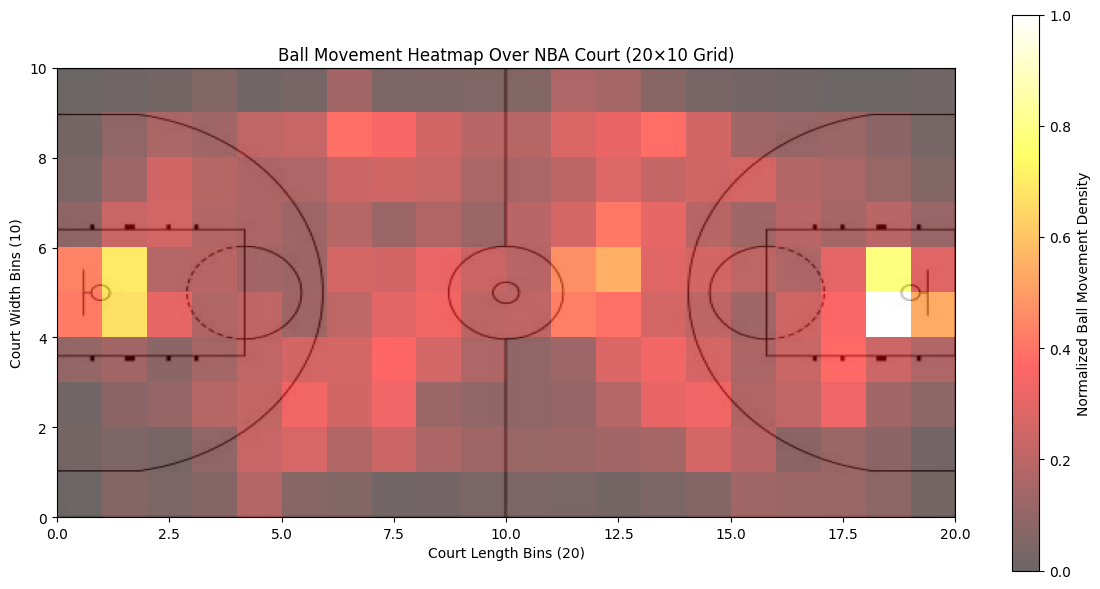

In [25]:
court_img = Image.open("court.jpg")

court_length = 94  # NBA court length in feet
court_width = 50   # NBA court width in feet

x_bins = 20  # number of horizontal bins
y_bins = 10  # number of vertical bins

# --- Discretize x and y positions into grid indices ---
last_rows_in_order['x_bin'] = np.clip((last_rows_in_order['x'] / court_length * x_bins).astype(int), 0, x_bins - 1)
last_rows_in_order['y_bin'] = np.clip((last_rows_in_order['y'] / court_width * y_bins).astype(int), 0, y_bins - 1)

# --- Create Heatmap Matrix ---
heatmap = np.zeros((x_bins, y_bins))
for _, row in last_rows_in_order.iterrows():
    heatmap[row['x_bin'], row['y_bin']] += 1

# Normalize (optional, for better visualization)
heatmap_normalized = heatmap / np.max(heatmap)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Show court image behind the heatmap
ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')

# Show heatmap overlay
heatmap_img = ax.imshow(
    heatmap_normalized.T,
    cmap='hot',
    origin='lower',
    extent=[0, x_bins, 0, y_bins],
    alpha=0.6  # transparency
)

# Add labels and colorbar
plt.colorbar(heatmap_img, ax=ax, label='Normalized Ball Movement Density')
ax.set_title("Ball Movement Heatmap Over NBA Court (20×10 Grid)")
ax.set_xlabel("Court Length Bins (20)")
ax.set_ylabel("Court Width Bins (10)")
plt.tight_layout()
plt.show()

In [26]:
# First plot above
# Rotate points 180 degrees if their y-axis is above 47 feet

last_rows_in_order = last_rows_in_order.drop(columns=["x_bin", "y_bin"])

In [27]:
movement_df = last_rows_in_order.copy()

mask = movement_df['x'] >= 47

movement_df.loc[mask, 'x'] = 94 - movement_df.loc[mask, 'x']
movement_df.loc[mask, 'y'] = 50 - movement_df.loc[mask, 'y']
# This is likely incorrrect...

In [28]:
movement_df.describe()

,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored
count,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000
mean,2.435974,369.001910,24.048185,25.085038,4.180343,378.520591,359.493608,99.889474,50.806507,50.806507,1.002620,0.459656
std,1.148374,201.659987,13.148305,11.267705,2.778458,201.928328,201.320903,57.279560,28.809451,28.809451,1.177538,0.498376
min,1.000000,0.020000,-5.623690,-0.804410,0.000000,13.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,199.670000,11.985045,16.656157,2.497147,215.000000,196.000000,51.000000,26.000000,26.000000,0.000000,0.000000
50%,2.000000,387.800000,25.618390,25.043710,3.571610,405.000000,377.000000,98.000000,50.000000,50.000000,0.000000,0.000000
75%,4.000000,539.120000,35.271610,33.559323,4.909257,546.000000,532.000000,154.000000,78.000000,78.000000,2.000000,1.000000
max,4.000000,720.000000,46.999710,51.328760,17.700760,720.000000,703.000000,204.000000,103.000000,103.000000,4.000000,1.000000


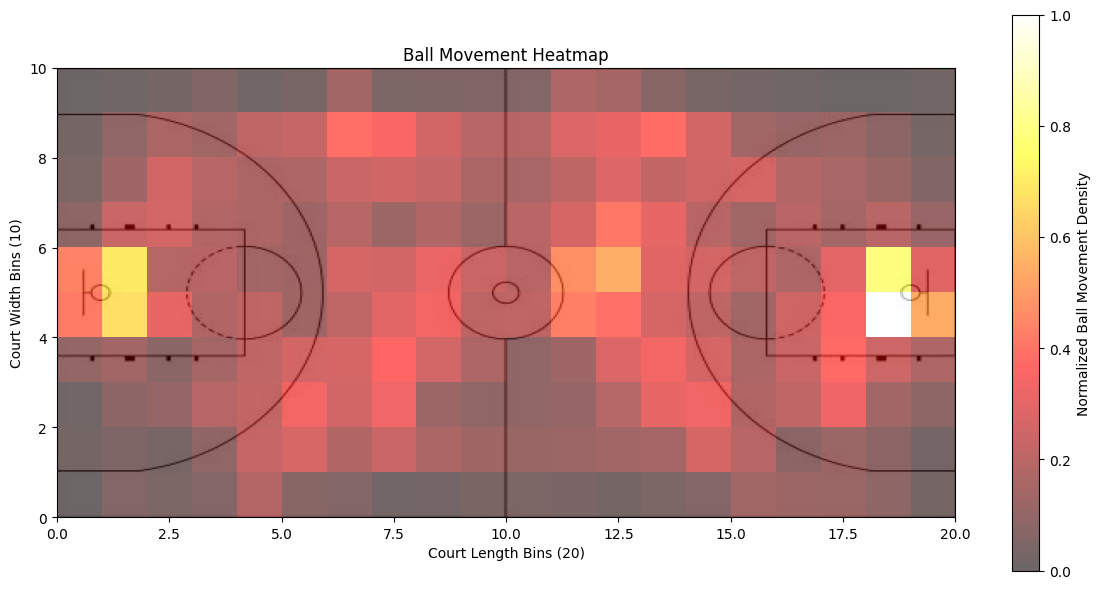

In [29]:
def heat(df, img, title = "Ball Movement Heatmap"):
    
    court_img = Image.open(img)

    court_length = 94  # NBA court length in feet (reduced)
    court_width = 50   # NBA court width in feet

    x_bins = 20  # number of horizontal bins
    y_bins = 10  # number of vertical bins
    
    # --- Discretize x and y positions into grid indices ---
    df['x_bin'] = np.clip((df['x'] / court_length * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / court_width * y_bins).astype(int), 0, y_bins - 1)
    
    # --- Create Heatmap Matrix ---
    heatmap = np.zeros((x_bins, y_bins))
    for _, row in df.iterrows():
        heatmap[row['x_bin'], row['y_bin']] += 1
    
    # Normalize (optional, for better visualization)
    heatmap_normalized = heatmap / np.max(heatmap)
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Show court image behind the heatmap
    ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')
    
    # Show heatmap overlay
    heatmap_img = ax.imshow(
    heatmap_normalized.T,
    cmap='hot',
    origin='lower',
    extent=[0, x_bins, 0, y_bins],
    alpha=0.6  # transparency
    )
    
    # Add labels and colorbar
    plt.colorbar(heatmap_img, ax=ax, label='Normalized Ball Movement Density')
    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (20)")
    ax.set_ylabel("Court Width Bins (10)")
    plt.tight_layout()
    plt.show()

heat(last_rows_in_order, "court.jpg", )

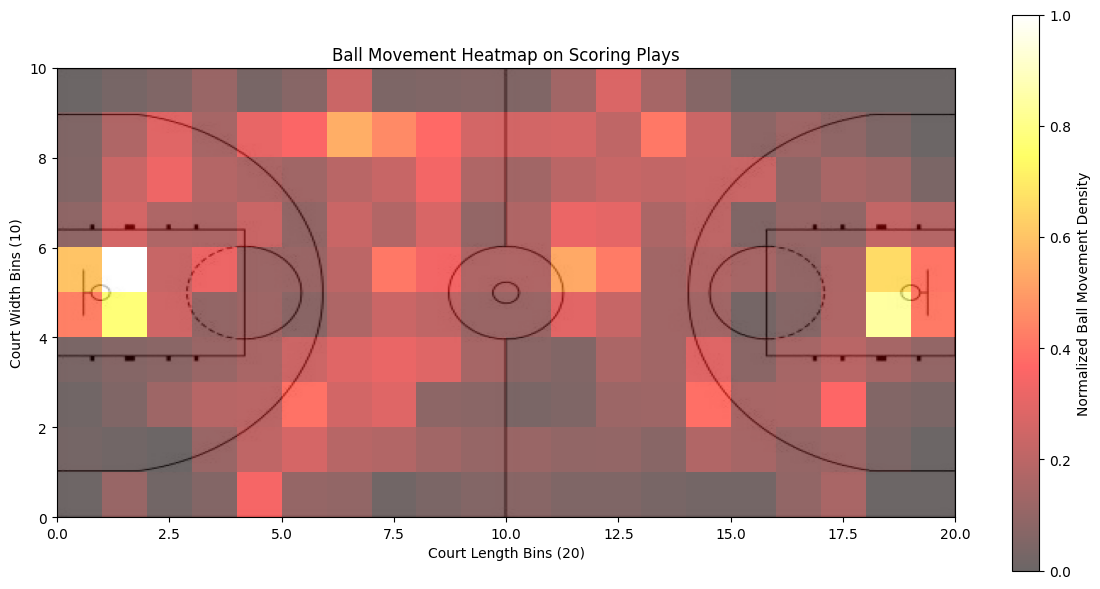

In [30]:
heat(last_rows_in_order[last_rows_in_order["scored"] == 1], "court.jpg", "Ball Movement Heatmap on Scoring Plays")

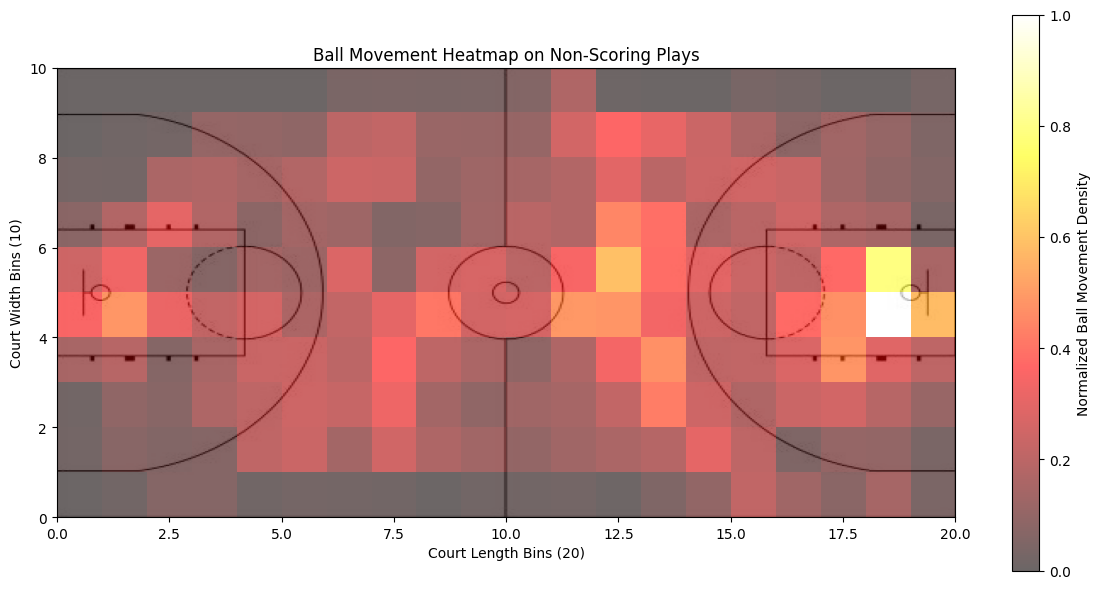

In [31]:
heat(last_rows_in_order[last_rows_in_order["scored"] == 0], "court.jpg", "Ball Movement Heatmap on Non-Scoring Plays")
# Why does the ball seem to have more movement on non-scoring plays?
# Less efficient movement?
# Maybe filter on the z-axis to remove some noise from the basket area?

## Conditional Scoring Probability by Sector

We estimate the conditional probability that a possession results in a score **given that the ball passed through a specific sector** of the court.

Let $\mathcal{M} = \left\{ (i, j) \mid 0 \leq i < N_x,\; 0 \leq j < N_y \right\}$ be the set of spatial bins on the court.

For each possession $p$, we define:
- $\mathcal{V}_p \subseteq \mathcal{M}$ as the set of all bins visited during possession $p$
- $s_p \in \{0, 1\}$ as an indicator whether the possession resulted in a score

We define two matrices:
- $T(i, j)$: total number of possessions that entered bin $(i, j)$
- $S(i, j)$: number of **scored** possessions that entered bin $(i, j)$

Then the estimated conditional scoring probability is:

$$
P(\text{score} \mid (i, j)) = 
\begin{cases}
\dfrac{S(i, j)}{T(i, j)} & \text{if } T(i, j) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

This is implemented in code by iterating over all possessions, marking visited bins, and updating counts for $T(i, j)$ and $S(i, j)$. The resulting probability matrix is visualized as a heatmap overlayed on a court image.

We set the dimensions of the court to 20x10 for easy comparison to our ball movement heatmaps and included a filter in a second method to disregard any sectors that had less than $\mathcal{n}$ possesions move through it where $n \in \mathbb{N}$.

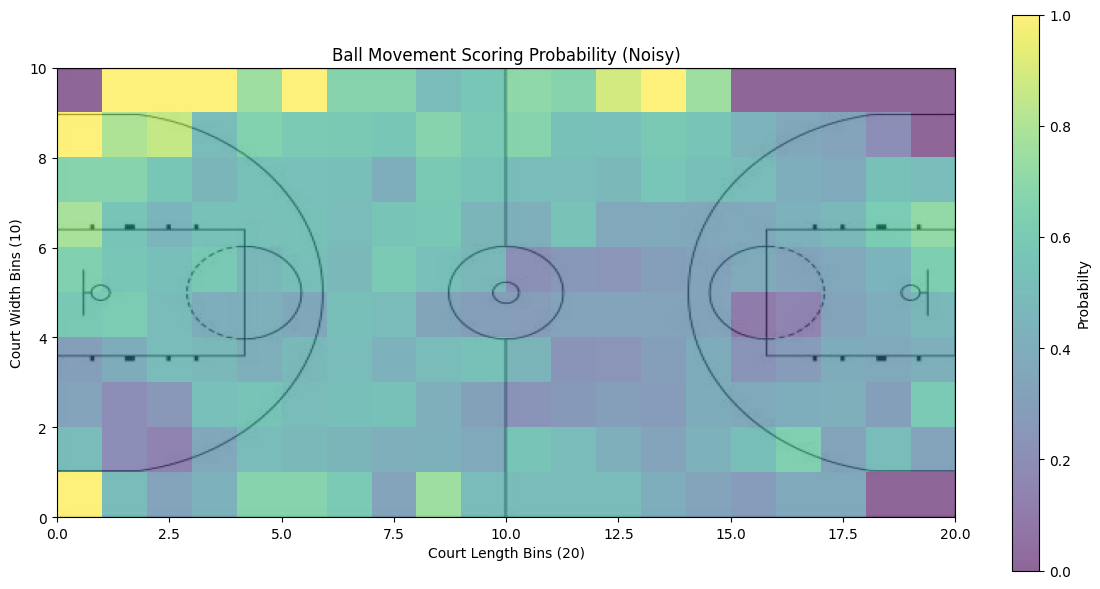

In [32]:
def calculate_score_probability_matrix(df, x_bins=20, y_bins=10):

    # Bin positions
    df['x_bin'] = np.clip((df['x'] / 94 * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / 50 * y_bins).astype(int), 0, y_bins - 1)

    # Initialize per-bin possession counters
    total_possessions = np.zeros((x_bins, y_bins))
    scored_possessions = np.zeros((x_bins, y_bins))

    # Count unique possessions that entered each bin
    grouped = df.groupby("possession_number")
    for _, group in grouped:
        visited = set(zip(group['x_bin'], group['y_bin']))
        scored = group['scored'].iloc[0]  # same for all rows in a possession
        for xb, yb in visited:
            total_possessions[xb, yb] += 1
            if scored == 1:
                scored_possessions[xb, yb] += 1

    # Compute probability matrix
    with np.errstate(divide='ignore', invalid='ignore'):
        probability_matrix = np.true_divide(scored_possessions, total_possessions)
        probability_matrix[~np.isfinite(probability_matrix)] = 0  # Set NaNs and infs to 0

    return probability_matrix

prob_matrix = calculate_score_probability_matrix(last_rows_in_order)

court_img = Image.open("court.jpg")

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, 20, 0, 10], aspect='auto')
overlay = ax.imshow(
    prob_matrix.T,
    cmap='viridis',
    origin='lower',
    extent=[0, 20, 0, 10],
    alpha=0.6
)

plt.colorbar(overlay, ax=ax, label='Probabilty')
ax.set_title("Ball Movement Scoring Probability (Noisy)")
ax.set_xlabel("Court Length Bins (20)")
ax.set_ylabel("Court Width Bins (10)")
plt.tight_layout()
plt.show()

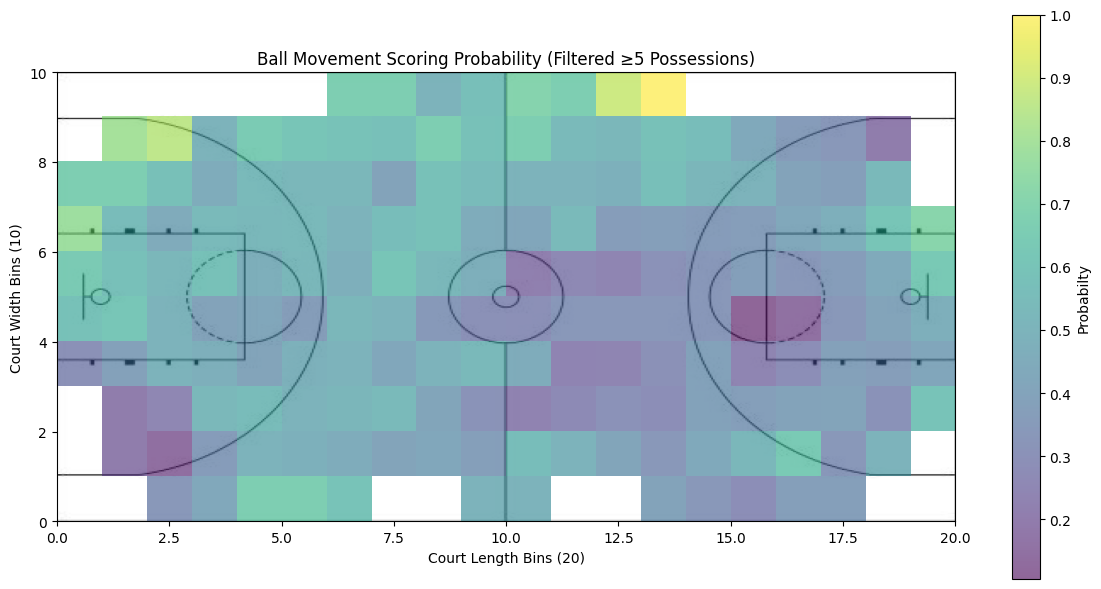

In [33]:
def calculate_score_probability_matrix_filter(df, min_visits, x_bins=20, y_bins=10):

    # Bin positions
    df['x_bin'] = np.clip((df['x'] / 94 * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / 50 * y_bins).astype(int), 0, y_bins - 1)

    # Initialize per-bin possession counters
    total_possessions = np.zeros((x_bins, y_bins))
    scored_possessions = np.zeros((x_bins, y_bins))

    # Count unique possessions that entered each bin
    for _, group in df.groupby("possession_number"):
        visited_bins = set(zip(group['x_bin'], group['y_bin']))
        scored = group['scored'].iloc[0]  # same for all rows in a possession
        for xb, yb in visited_bins:
            total_possessions[xb, yb] += 1
            if scored == 1:
                scored_possessions[xb, yb] += 1

    # Calculate conditional probabilities
    with np.errstate(divide='ignore', invalid='ignore'):
        prob_matrix = scored_possessions / total_possessions
        prob_matrix[~np.isfinite(prob_matrix)] = 0

    # Filter out bins with too few possessions
    prob_matrix[total_possessions < min_visits] = np.nan

    return prob_matrix

min_visits = 5

prob_matrix = calculate_score_probability_matrix_filter(last_rows_in_order, min_visits, x_bins=20, y_bins=10)
court_img = Image.open("court.jpg")

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, 20, 0, 10], aspect='auto')
overlay = ax.imshow(
    prob_matrix.T,
    cmap='viridis',
    origin='lower',
    extent=[0, 20, 0, 10],
    alpha=0.6
)

plt.colorbar(overlay, ax=ax, label='Probabilty')
ax.set_title(f"Ball Movement Scoring Probability (Filtered ≥{min_visits} Possessions)")
ax.set_xlabel("Court Length Bins (20)")
ax.set_ylabel("Court Width Bins (10)")
plt.tight_layout()
plt.show()

In [34]:
# High probability towards the boundaries. Inbound passes?
# Probability is higher than expected in most zones. Filter z-axis? 

## Plotting Possessions to Improve Analysis

The heatmaps are useful, but we can add more context to them before doing breakdown analysis by analyzing plays visually. This will hopefully clear up the picture as to why the ball moves more during non-scoring plays, and as to why plays that move along the bottom side of the court are so effective.

This will also allow us to see how noisy some of our data is, or if it's even tracked correctly.

In [35]:
movement_df.to_csv("Data/movement_csv.csv")

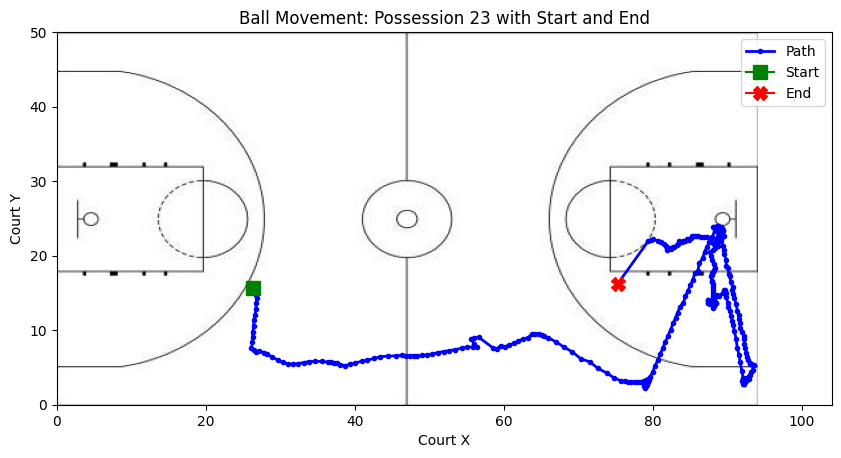

In [36]:
def movement_plot_possession(df, possession, image):
    court_img = mpimg.imread(image)
    
    # Filter a specific possession
    sub_df = df[df["possession_number"] == possession].sort_values(by="time", ascending=False)
    
    # Get start and end positions
    start_x, start_y = sub_df.iloc[0][["x", "y"]]
    end_x, end_y = sub_df.iloc[-1][["x", "y"]]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(court_img, extent=[0, 94, 0, 50])
    ax.plot(sub_df["x"], sub_df["y"], color="blue", linewidth=2, marker="o", markersize=3, label="Path")
    
    # Start marker
    ax.plot(start_x, start_y, marker="s", color="green", markersize=10, label="Start")
    
    # End marker
    ax.plot(end_x, end_y, marker="X", color="red", markersize=10, label="End")
    
    # Styling
    ax.set_xlim(0, 104)
    ax.set_ylim(0, 50)
    ax.set_title(f"Ball Movement: Possession {possession} with Start and End")
    ax.set_xlabel("Court X")
    ax.set_ylabel("Court Y")
    ax.legend()
    
    plt.show()

movement_plot_possession(last_rows_in_order, 23,"court.jpg")
# 20, 29

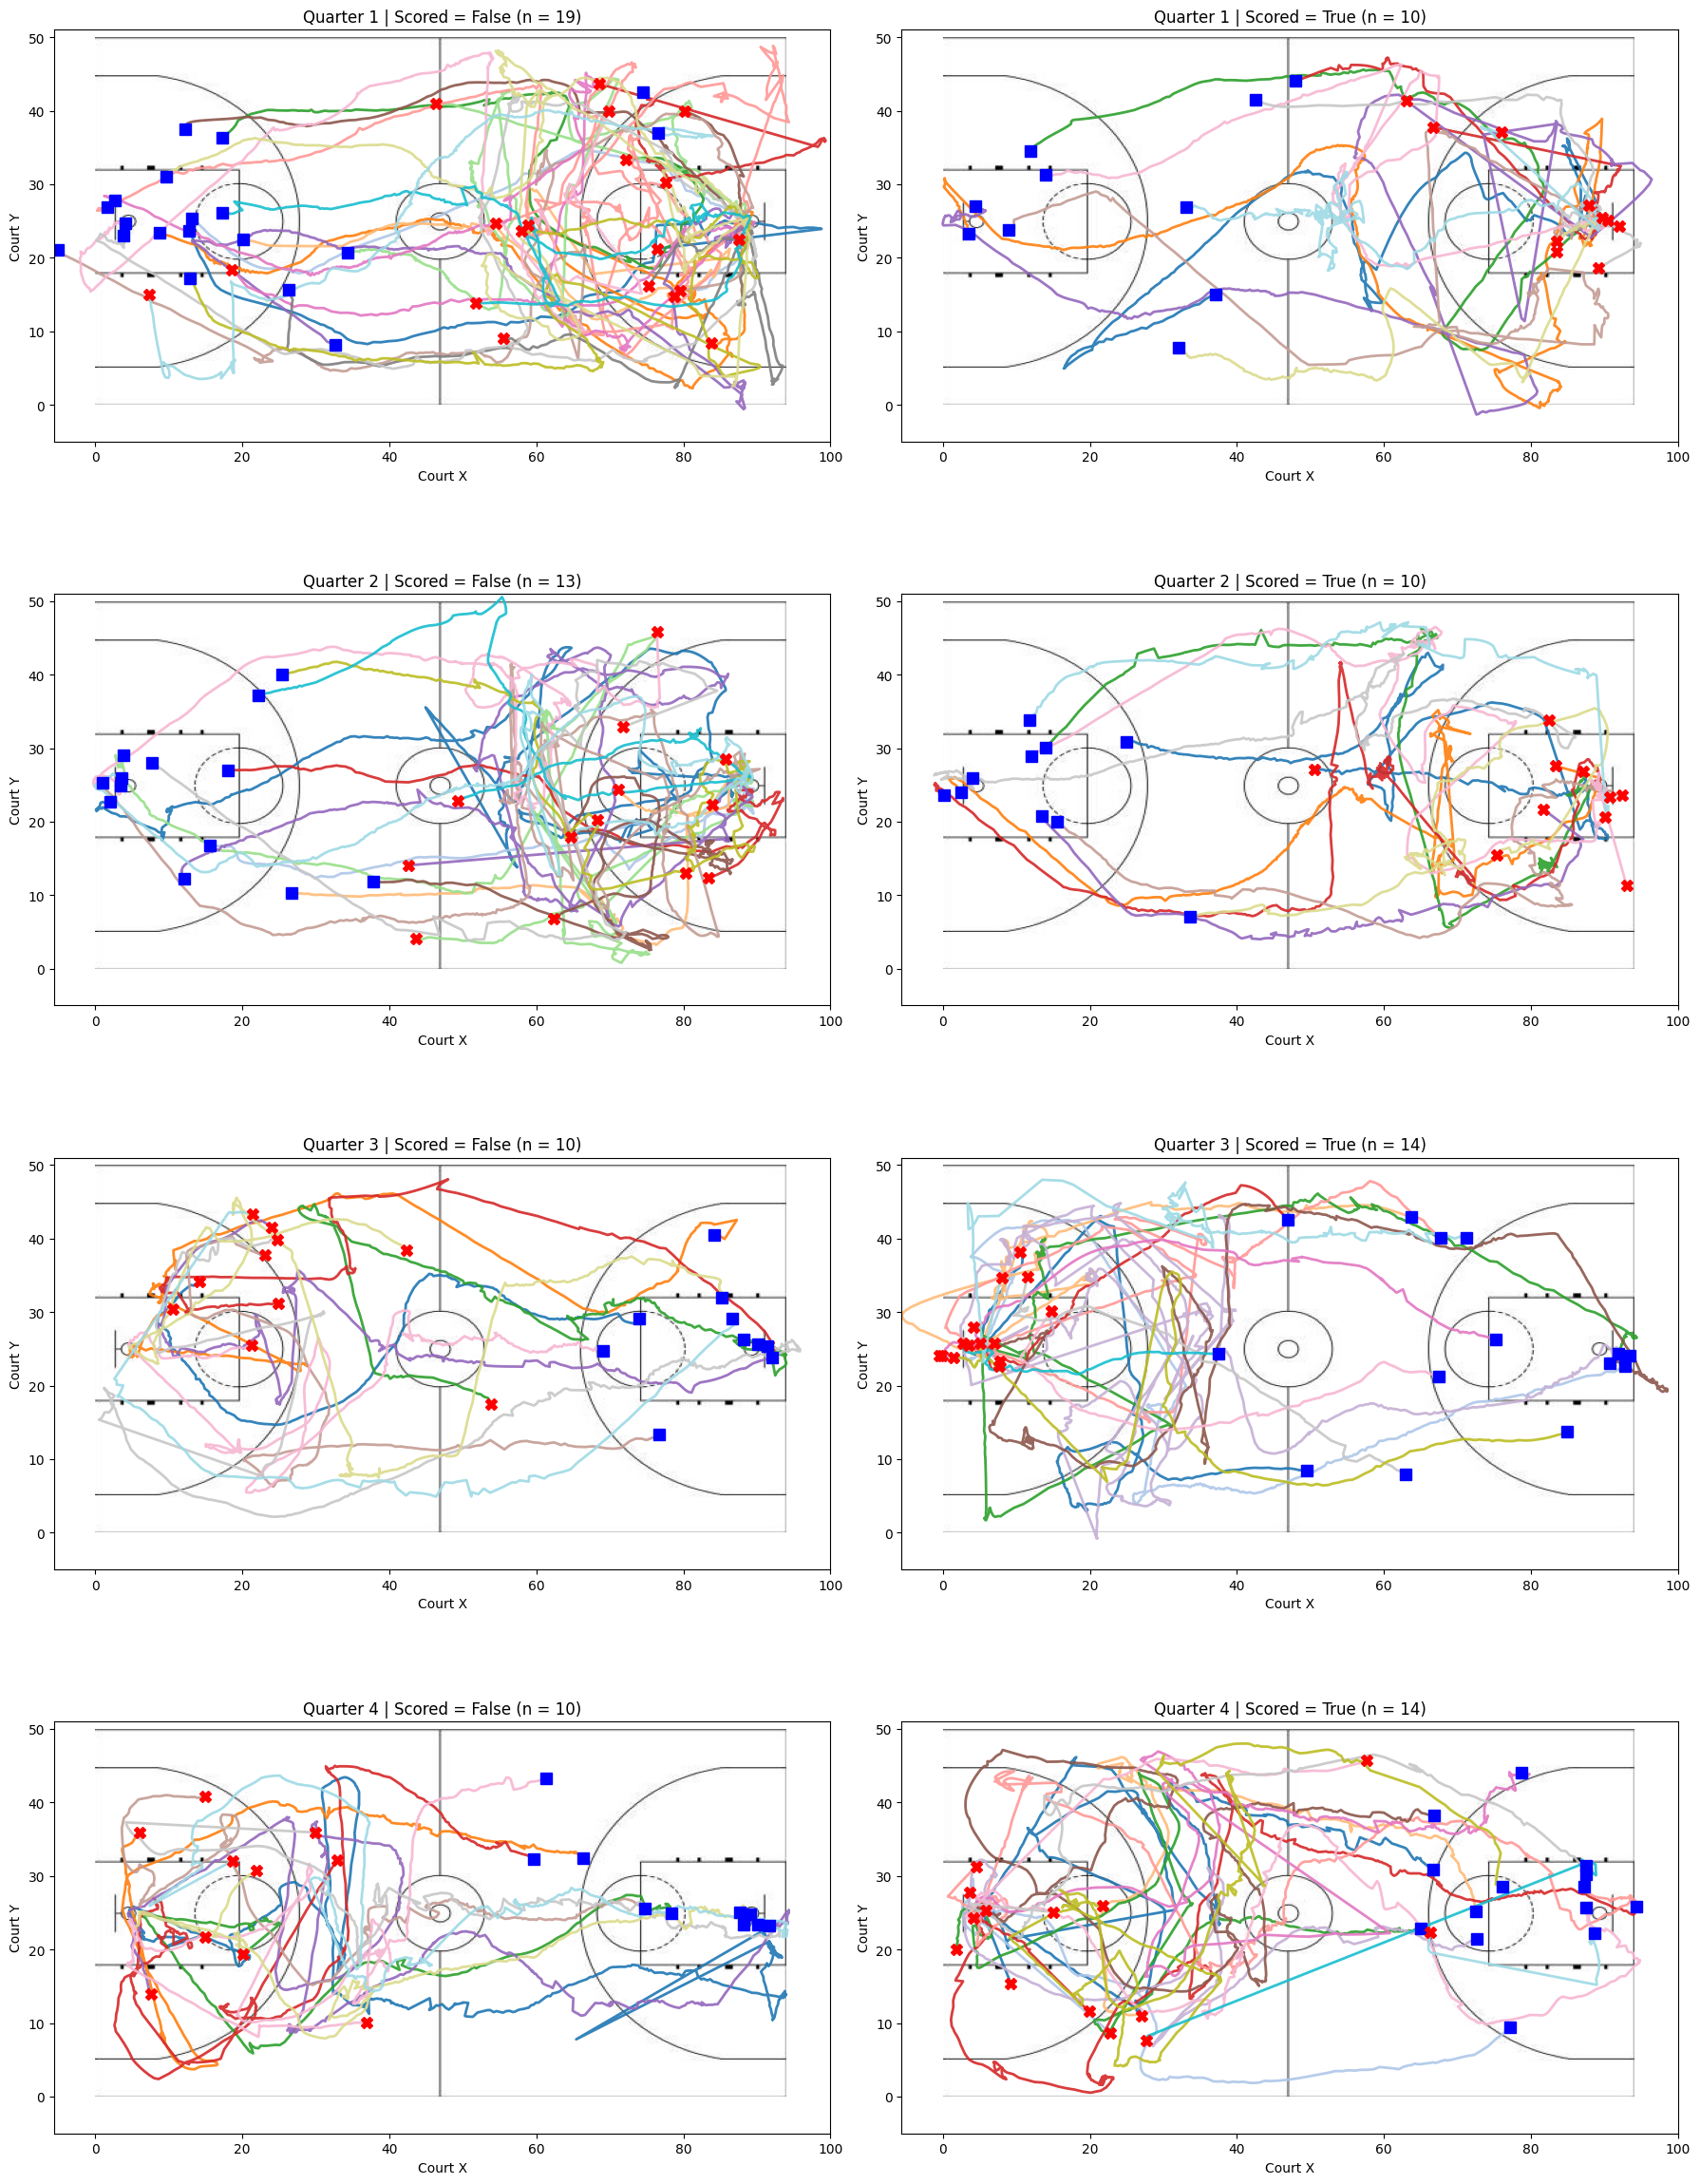

In [37]:
def movement_plot_all_quarters(df, image):
    court_img = mpimg.imread(image)
    fig, axes = plt.subplots(4, 2, figsize=(18, 24))

    # Define fixed court image extent
    court_extent = [0, 94, 0, 50]

    # Compute axis limits based on data, allowing buffer
    x_min, x_max = min(-5, df["x"].min()), max(100, df["x"].max())
    y_min, y_max = min(-5, df["y"].min()), max(51, df["y"].max())

    for row, quarter in enumerate([1, 2, 3, 4]):
        for col, scored in enumerate([0, 1]):
            ax = axes[row, col]
            scored_df = df[(df["period"] == quarter) & (df["scored"] == scored)]
            possession_ids = scored_df["possession_number"].unique()
            possession_count = len(possession_ids)
            cmap = cm.get_cmap('tab20', max(possession_count, 1))

            # Show fixed-size court image
            ax.imshow(court_img, extent=court_extent, zorder=0)

            # Extend the axes beyond court image
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_title(f"Quarter {quarter} | Scored = {bool(scored)} (n = {possession_count})")
            ax.set_xlabel("Court X")
            ax.set_ylabel("Court Y")

            for i, pid in enumerate(possession_ids):
                group = scored_df[scored_df["possession_number"] == pid].sort_values(by="time", ascending=False)
                start_x, start_y = group.iloc[0][["x", "y"]]
                end_x, end_y = group.iloc[-1][["x", "y"]]
                color = cmap(i)
                ax.plot(group["x"], group["y"], color=color, linewidth=2, alpha=0.9, zorder=1)
                ax.plot(start_x, start_y, marker="s", color="blue", markersize=8, zorder=2)
                ax.plot(end_x, end_y, marker="X", color="red", markersize=8, zorder=2)

    plt.tight_layout()
    plt.show()

# Usage
movement_plot_all_quarters(last_rows_in_order, "court.jpg")

In [38]:
last_rows_in_order.describe()

,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored,x_bin,y_bin
count,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000,38172.000000
mean,2.435974,369.001910,48.875523,25.256536,4.180343,378.520591,359.493608,99.889474,50.806507,50.806507,1.002620,0.459656,9.887090,4.554700
std,1.148374,201.659987,26.384842,11.265105,2.778458,201.928328,201.320903,57.279560,28.809451,28.809451,1.177538,0.498376,5.590478,2.275138
min,1.000000,0.020000,-5.623690,-1.328760,0.000000,13.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,199.670000,27.391987,17.166935,2.497147,215.000000,196.000000,51.000000,26.000000,26.000000,0.000000,0.000000,5.000000,3.000000
50%,2.000000,387.800000,51.480305,25.021295,3.571610,405.000000,377.000000,98.000000,50.000000,50.000000,0.000000,0.000000,10.000000,5.000000
75%,4.000000,539.120000,70.102442,34.050360,4.909257,546.000000,532.000000,154.000000,78.000000,78.000000,2.000000,1.000000,14.000000,6.000000
max,4.000000,720.000000,99.345540,50.564640,17.700760,720.000000,703.000000,204.000000,103.000000,103.000000,4.000000,1.000000,19.000000,9.000000


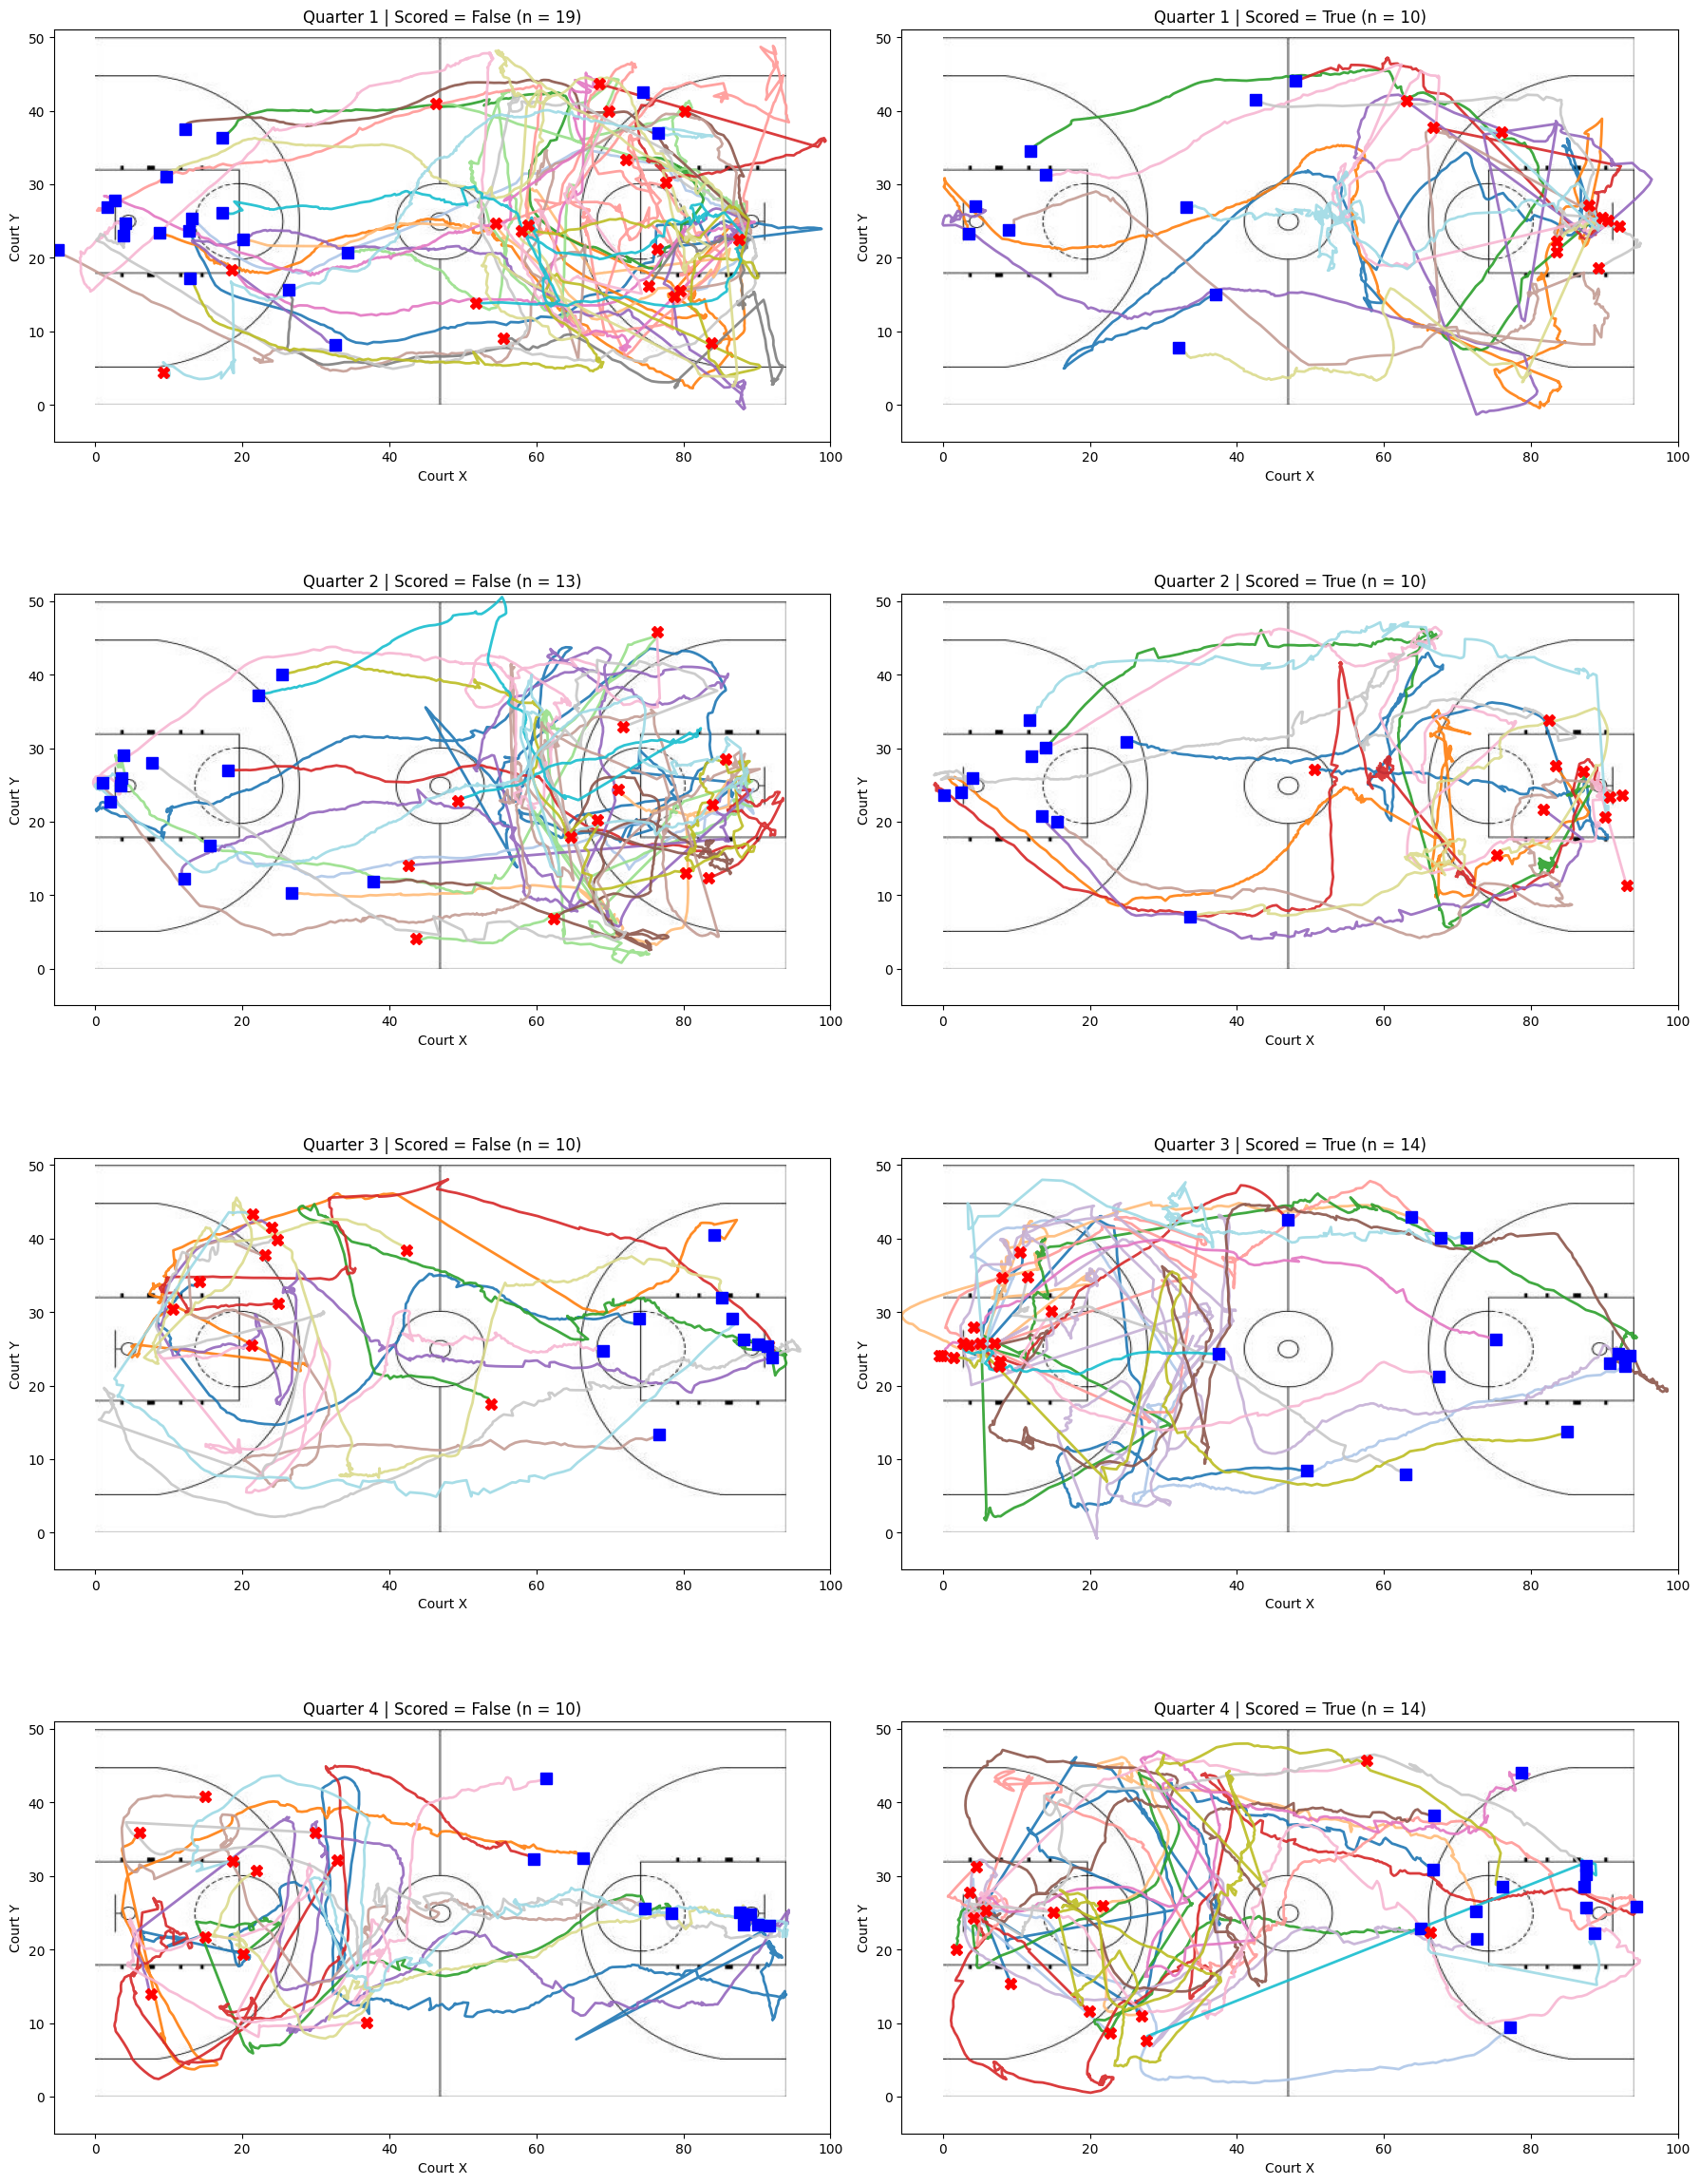

In [39]:
movement_plot_all_quarters(last_rows_in_order[last_rows_in_order["z"] < 10], "court.jpg")

In [40]:
def heat(df, img, ax, title="Ball Movement Heatmap"):
    court_img = Image.open(img)

    court_length = 94  # NBA court length in feet
    court_width = 50   # NBA court width in feet

    x_bins = 20
    y_bins = 10

    # Bin the coordinates
    df['x_bin'] = np.clip((df['x'] / court_length * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / court_width * y_bins).astype(int), 0, y_bins - 1)

    # Create heatmap
    heatmap = np.zeros((x_bins, y_bins))
    for _, row in df.iterrows():
        heatmap[row['x_bin'], row['y_bin']] += 1

    # Normalize
    heatmap_normalized = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap

    # Plot background court
    ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')

    # Overlay heatmap
    im = ax.imshow(
        heatmap_normalized.T,
        cmap='hot',
        origin='lower',
        extent=[0, x_bins, 0, y_bins],
        alpha=0.6
    )

    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (20)")
    ax.set_ylabel("Court Width Bins (10)")
    
    return im  # Return image object for colorbar

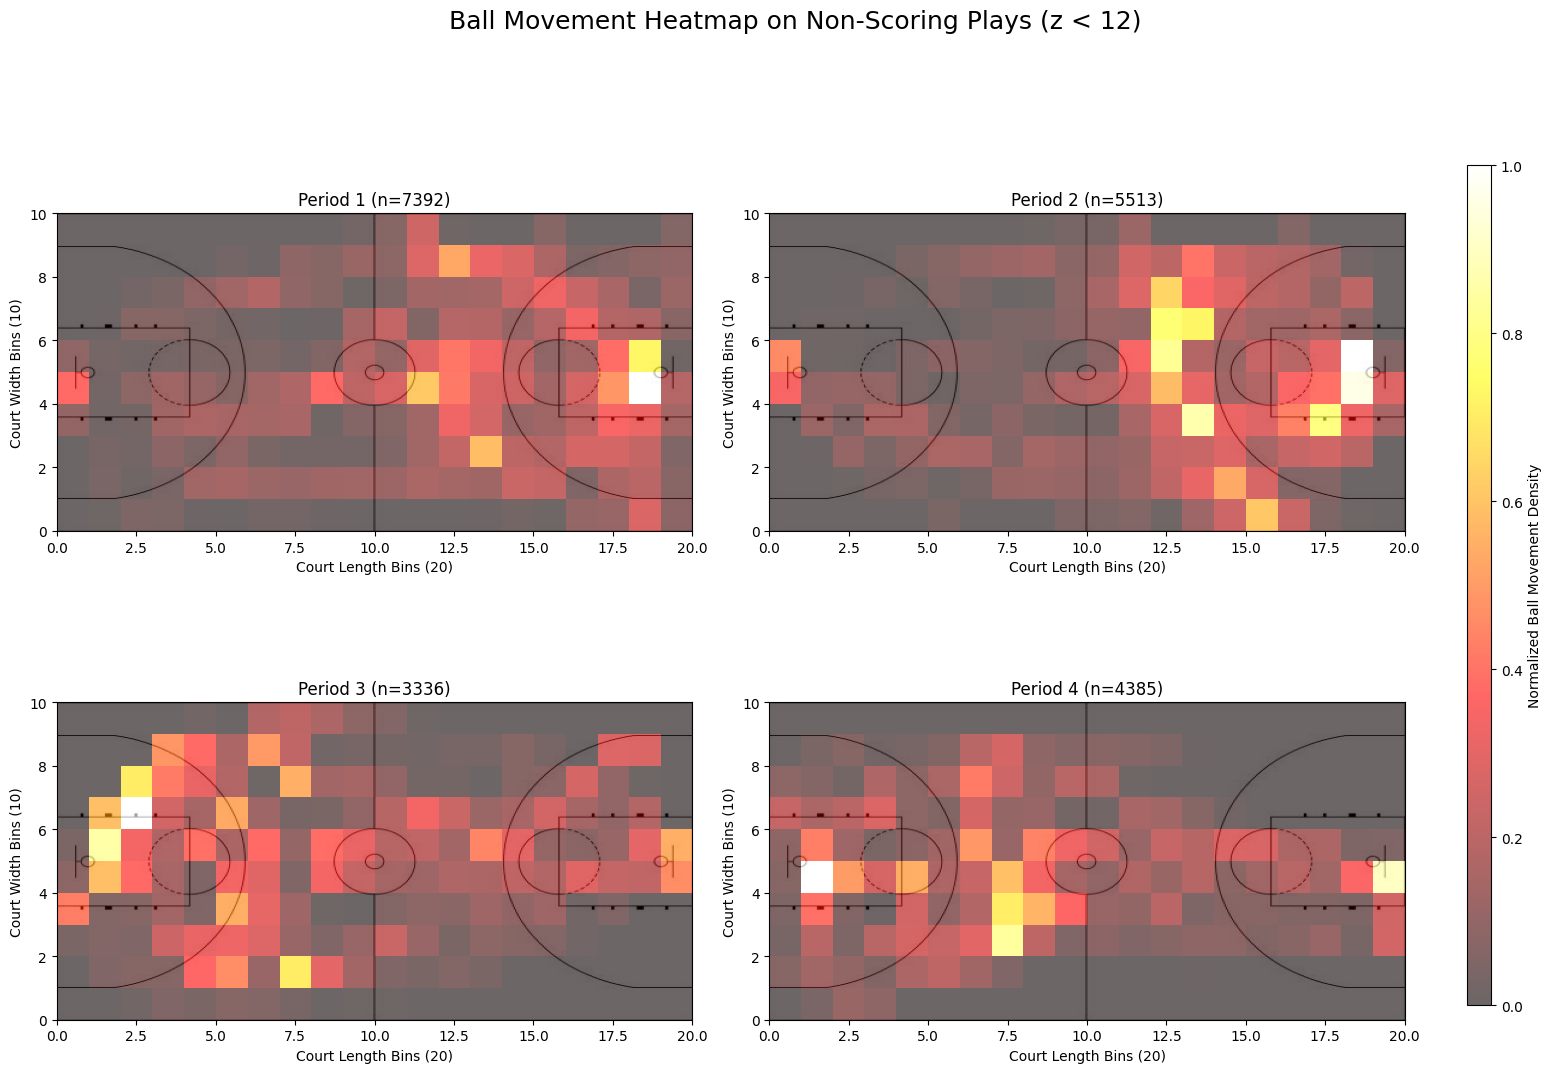

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Ball Movement Heatmap on Non-Scoring Plays (z < 12)", fontsize=18)

# Shared image and heatmap ranges
court_image_path = "court.jpg"
vmin, vmax = 0, 1  # consistent color scale if needed

# Track one of the returned im objects for colorbar
heatmap_images = []

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        (last_rows_in_order["scored"] == 0) &
        #(last_rows_in_order["z"] < 12) &
        (last_rows_in_order["period"] == period)
    ]
    im = heat(subset, court_image_path, ax, f"Period {period} (n={len(subset)})")
    heatmap_images.append(im)

# Add one shared colorbar (optional)
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])  # leave room for colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # colorbar axes
fig.colorbar(heatmap_images[0], cax=cbar_ax, label="Normalized Ball Movement Density")
plt.show()

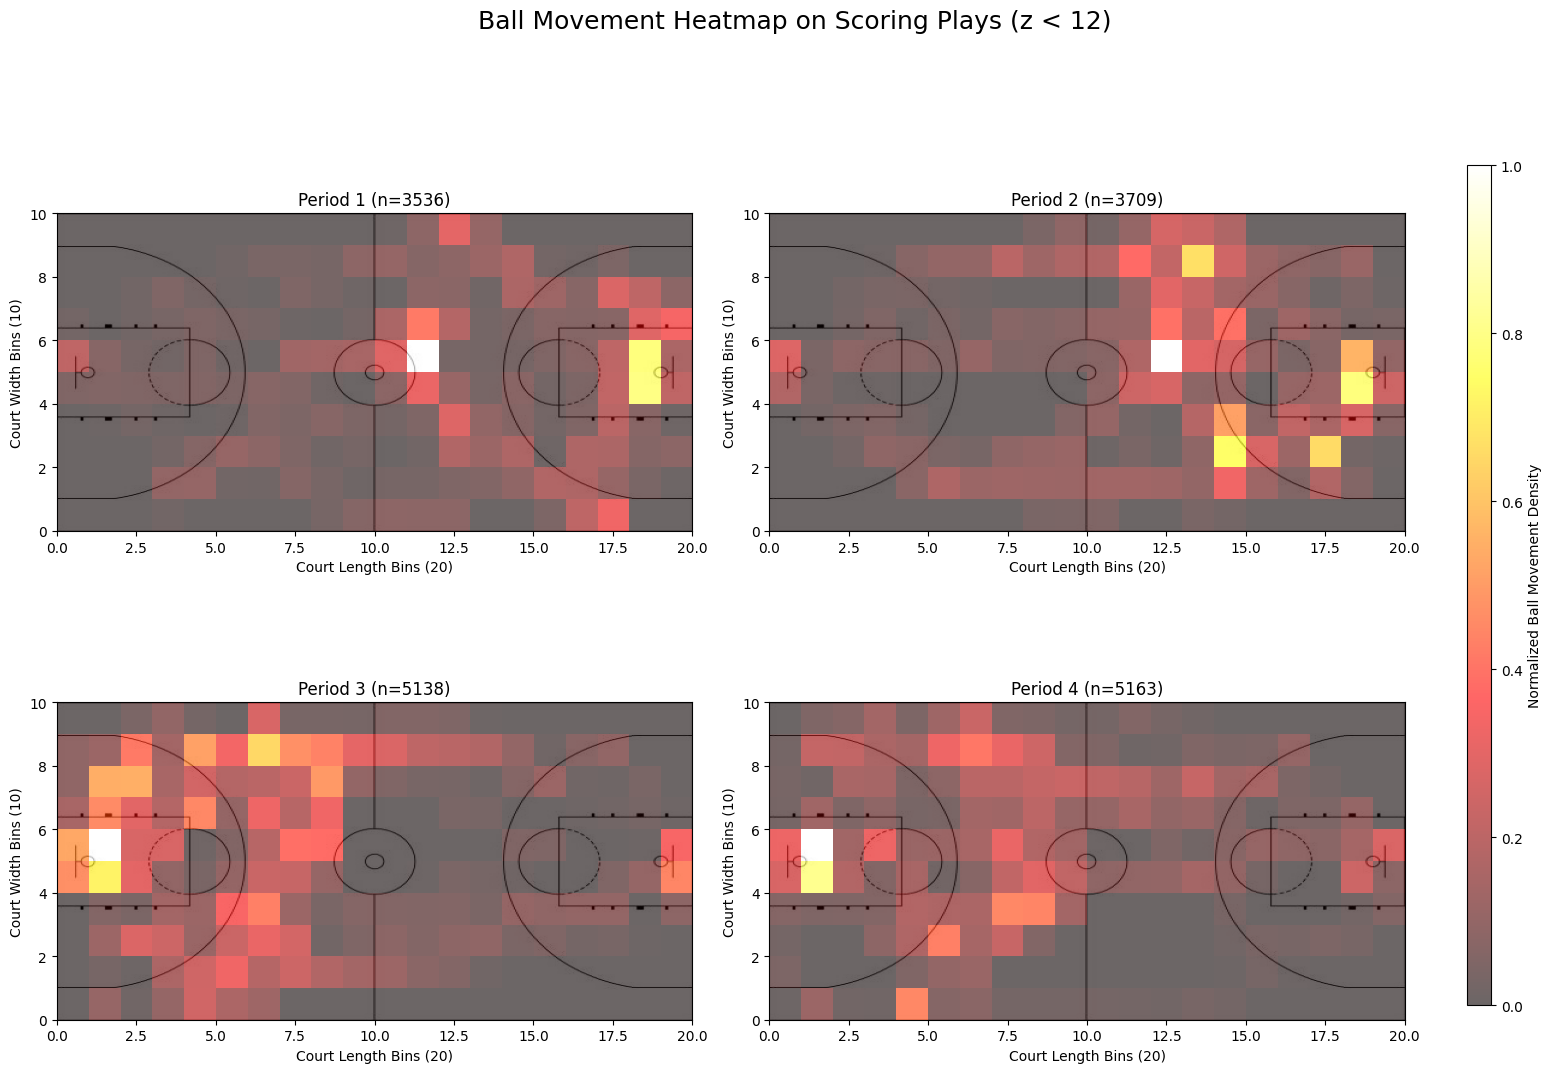

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Ball Movement Heatmap on Scoring Plays (z < 12)", fontsize=18)

# Shared image and heatmap ranges
court_image_path = "court.jpg"
vmin, vmax = 0, 1  # consistent color scale if needed

# Track one of the returned im objects for colorbar
heatmap_images = []

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        (last_rows_in_order["scored"] == 1) &
        #(last_rows_in_order["z"] < 12) &
        (last_rows_in_order["period"] == period)
    ]
    im = heat(subset, court_image_path, ax, f"Period {period} (n={len(subset)})")
    heatmap_images.append(im)

# Add one shared colorbar (optional)
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])  # leave room for colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # colorbar axes
fig.colorbar(heatmap_images[0], cax=cbar_ax, label="Normalized Ball Movement Density")
plt.show()

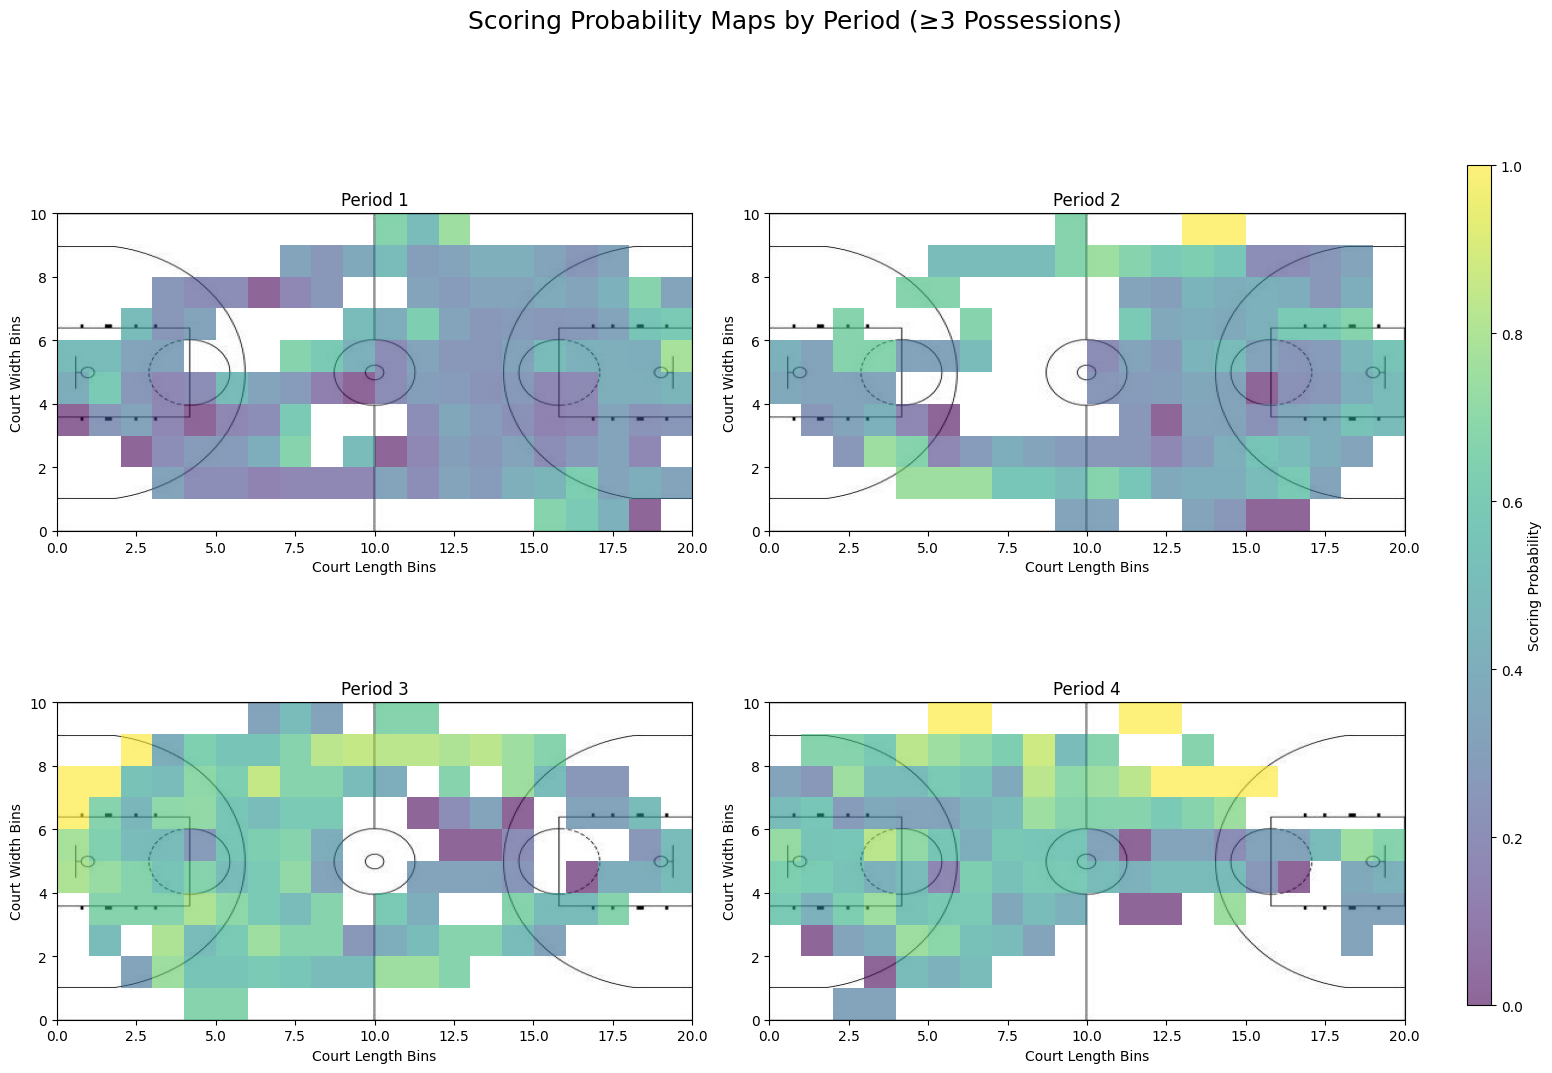

In [43]:
min_visits = 3
x_bins = 20
y_bins = 10
court_img = Image.open("court.jpg")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Scoring Probability Maps by Period (≥{min_visits} Possessions)", fontsize=18)

prob_maps = []  # to store overlay handles for shared colorbar

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        #(last_rows_in_order["z"] < 12) &
        (last_rows_in_order["period"] == period)
    ]

    prob_matrix = calculate_score_probability_matrix_filter(subset, min_visits, x_bins, y_bins)

    # Plot court image
    ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')

    # Overlay probability heatmap
    overlay = ax.imshow(
        prob_matrix.T,
        cmap='viridis',
        origin='lower',
        extent=[0, x_bins, 0, y_bins],
        alpha=0.6,
        vmin=0, vmax=1  # for consistent color scale across plots
    )

    ax.set_title(f"Period {period}")
    ax.set_xlabel("Court Length Bins")
    ax.set_ylabel("Court Width Bins")
    prob_maps.append(overlay)

# Add shared colorbar without overlapping subplots
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(prob_maps[0], cax=cbar_ax, label="Scoring Probability")

plt.show()

In [44]:
inverted = last_rows_in_order.copy()

mask = inverted["period"] > 2

inverted.loc[mask, "x_bin"] = 20 - inverted.loc[mask, "x_bin"]
inverted.loc[mask, "y_bin"] = 10 - inverted.loc[mask, "y_bin"]

In [45]:
def heat_invert(df, img, ax, title="Ball Movement Heatmap"):
    court_img = Image.open(img)

    court_length = 94
    court_width = 50
    x_bins, y_bins = 20, 10

    # Bin coordinates
    df['x_bin'] = np.clip((df['x'] / court_length * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / court_width * y_bins).astype(int), 0, y_bins - 1)

    # Flip bins for possessions going the other direction
    mask = df["period"] > 2
    df.loc[mask, "x_bin"] = x_bins - 1 - df.loc[mask, "x_bin"]
    df.loc[mask, "y_bin"] = y_bins - 1 - df.loc[mask, "y_bin"]

    df['x_bin'] = np.clip(df['x_bin'], 0, x_bins - 1)
    df['y_bin'] = np.clip(df['y_bin'], 0, y_bins - 1)

    # Heatmap computation
    heatmap = np.zeros((x_bins, y_bins))
    np.add.at(heatmap, (df['x_bin'], df['y_bin']), 1)

    # Normalize
    heatmap_normalized = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap

    # Plotting
    ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')
    im = ax.imshow(
        heatmap_normalized.T,
        cmap='hot',
        origin='lower',
        extent=[0, x_bins, 0, y_bins],
        alpha=0.6
    )
    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (20)")
    ax.set_ylabel("Court Width Bins (10)")
    
    return im

In [46]:
def calculate_score_probability_matrix_filter_inverted(df, min_visits, x_bins=20, y_bins=10):

    # Bin positions
    df['x_bin'] = np.clip((df['x'] / 94 * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / 50 * y_bins).astype(int), 0, y_bins - 1)

    df['x_bin'] = np.clip((df['x'] / court_length * x_bins).astype(int), 0, x_bins - 1)
    df['y_bin'] = np.clip((df['y'] / court_width * y_bins).astype(int), 0, y_bins - 1)

    mask = df["period"] > 2
    df.loc[mask, "x_bin"] = x_bins - 1 - df.loc[mask, "x_bin"]
    df.loc[mask, "y_bin"] = y_bins - 1 - df.loc[mask, "y_bin"]

    df['x_bin'] = np.clip(df['x_bin'], 0, x_bins - 1)
    df['y_bin'] = np.clip(df['y_bin'], 0, y_bins - 1)

    # Initialize per-bin possession counters
    total_possessions = np.zeros((x_bins, y_bins))
    scored_possessions = np.zeros((x_bins, y_bins))

    # Count unique possessions that entered each bin
    for _, group in df.groupby("possession_number"):
        visited_bins = set(zip(group['x_bin'], group['y_bin']))
        scored = group['scored'].iloc[0]  # same for all rows in a possession
        for xb, yb in visited_bins:
            total_possessions[xb, yb] += 1
            if scored == 1:
                scored_possessions[xb, yb] += 1

    # Calculate conditional probabilities
    with np.errstate(divide='ignore', invalid='ignore'):
        prob_matrix = scored_possessions / total_possessions
        prob_matrix[~np.isfinite(prob_matrix)] = 0

    # Filter out bins with too few possessions
    prob_matrix[total_possessions < min_visits] = np.nan

    return prob_matrix

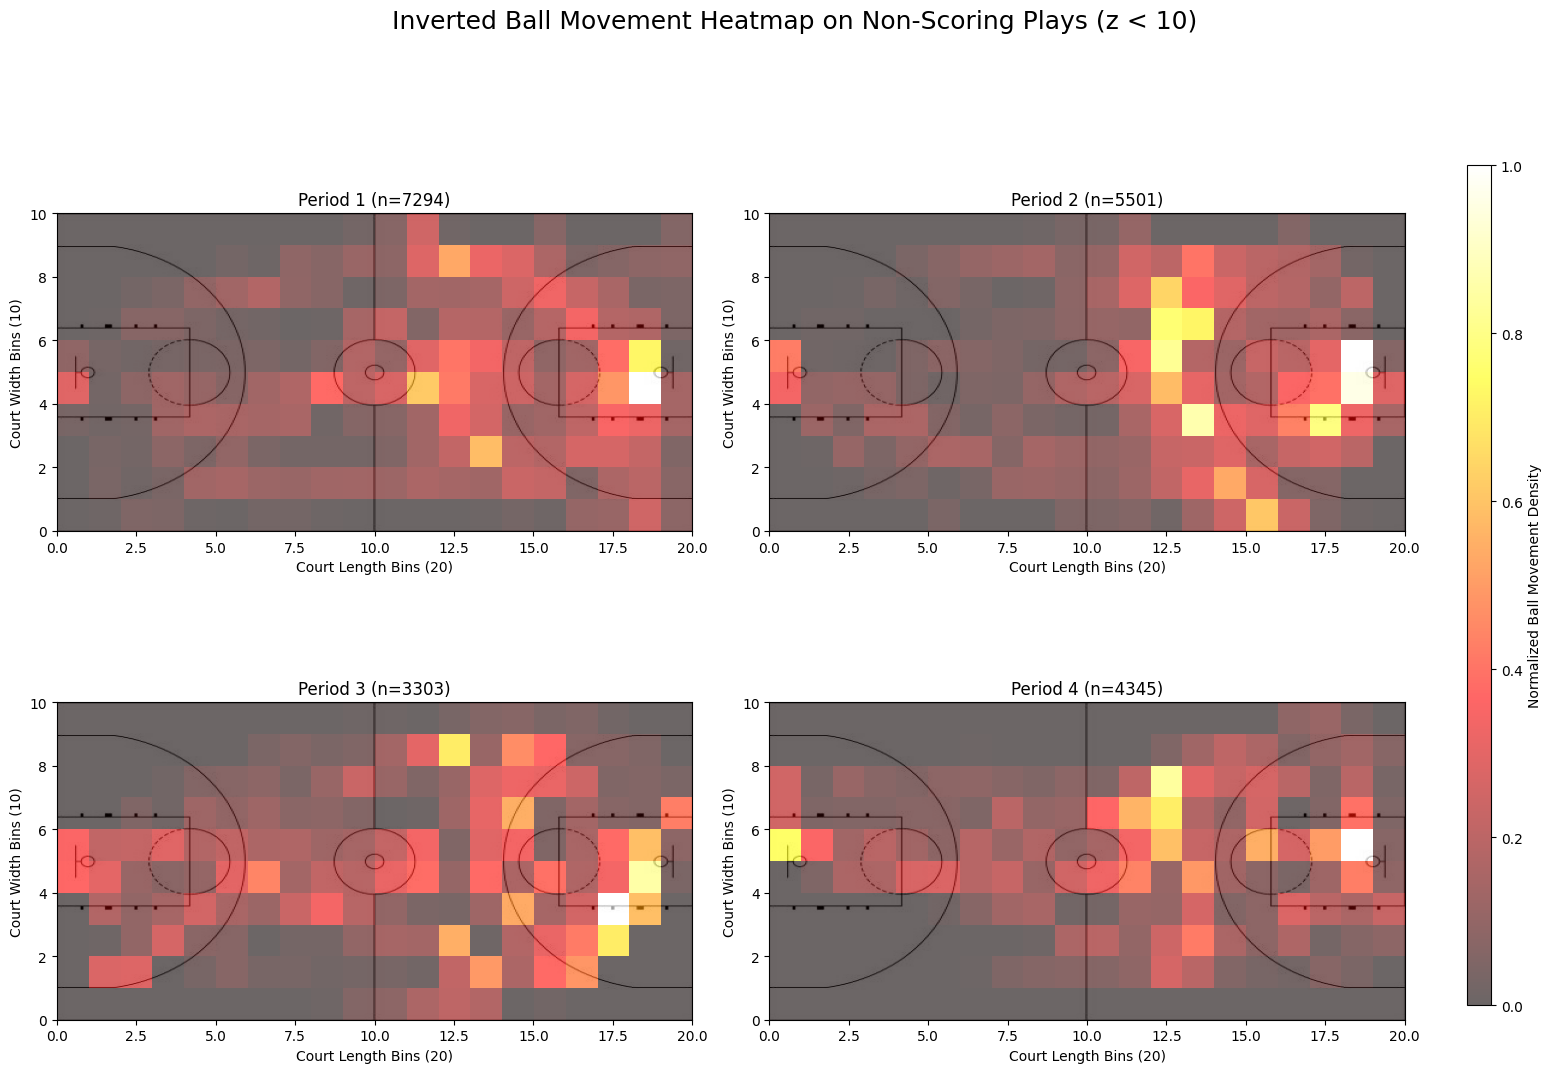

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Inverted Ball Movement Heatmap on Non-Scoring Plays (z < 10)", fontsize=18)

# Shared image and heatmap ranges
court_image_path = "court.jpg"
vmin, vmax = 0, 1  # consistent color scale if needed

# Track one of the returned im objects for colorbar
heatmap_images = []

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        (last_rows_in_order["scored"] == 0) &
        #(last_rows_in_order["z"] < 10) &
        (last_rows_in_order["period"] == period)
    ]
    subset = subset[(subset["x"] >= 0) & (subset["x"] <= 94) &
                    (subset["y"] >= 0) & (subset["y"] <= 50)]

    if subset.empty:
        ax.axis("off")
        continue

    im = heat_invert(subset, court_image_path, ax, f"Period {period} (n={len(subset)})")
    heatmap_images.append(im)

# Add one shared colorbar (optional)
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])  # leave room for colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # colorbar axes
fig.colorbar(heatmap_images[0], cax=cbar_ax, label="Normalized Ball Movement Density")
plt.show()

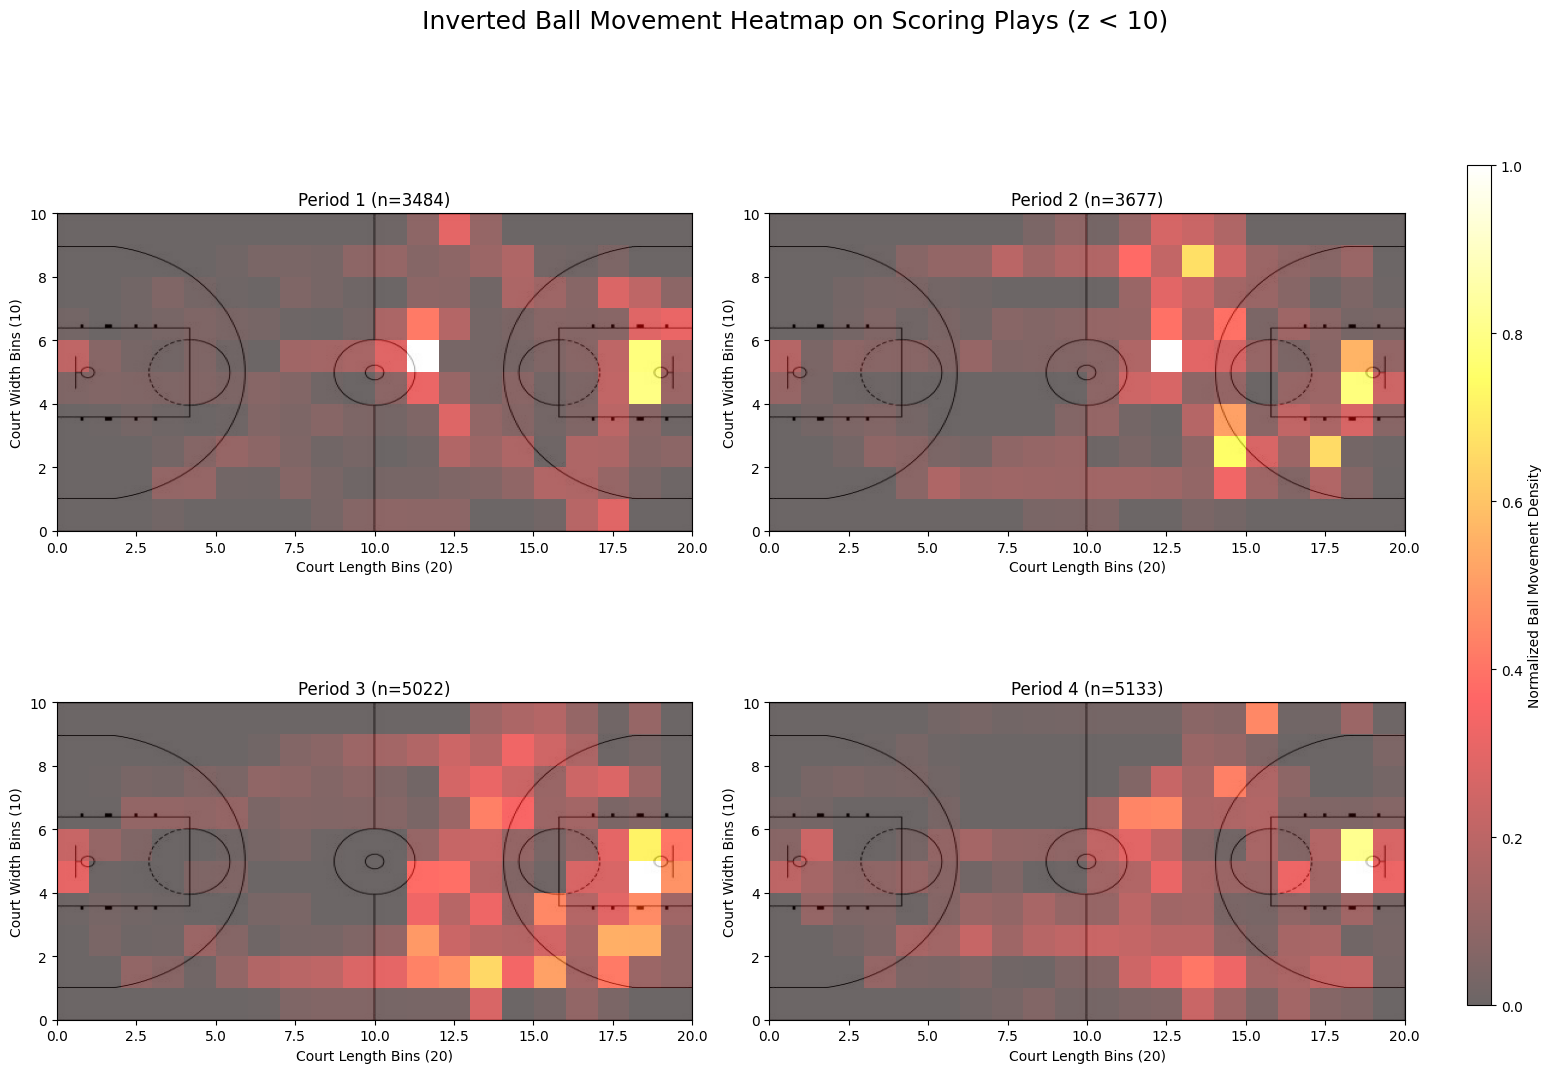

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Inverted Ball Movement Heatmap on Scoring Plays (z < 10)", fontsize=18)

# Shared image and heatmap ranges
court_image_path = "court.jpg"
vmin, vmax = 0, 1  # consistent color scale if needed

# Track one of the returned im objects for colorbar
heatmap_images = []

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        (last_rows_in_order["scored"] == 1) &
        #(last_rows_in_order["z"] < 10) &
        (last_rows_in_order["period"] == period)
    ]
    subset = subset[(subset["x"] >= 0) & (subset["x"] <= 94) &
                    (subset["y"] >= 0) & (subset["y"] <= 50)]

    if subset.empty:
        ax.axis("off")
        continue

    im = heat_invert(subset, court_image_path, ax, f"Period {period} (n={len(subset)})")
    heatmap_images.append(im)

# Add one shared colorbar (optional)
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])  # leave room for colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # colorbar axes
fig.colorbar(heatmap_images[0], cax=cbar_ax, label="Normalized Ball Movement Density")
plt.show()

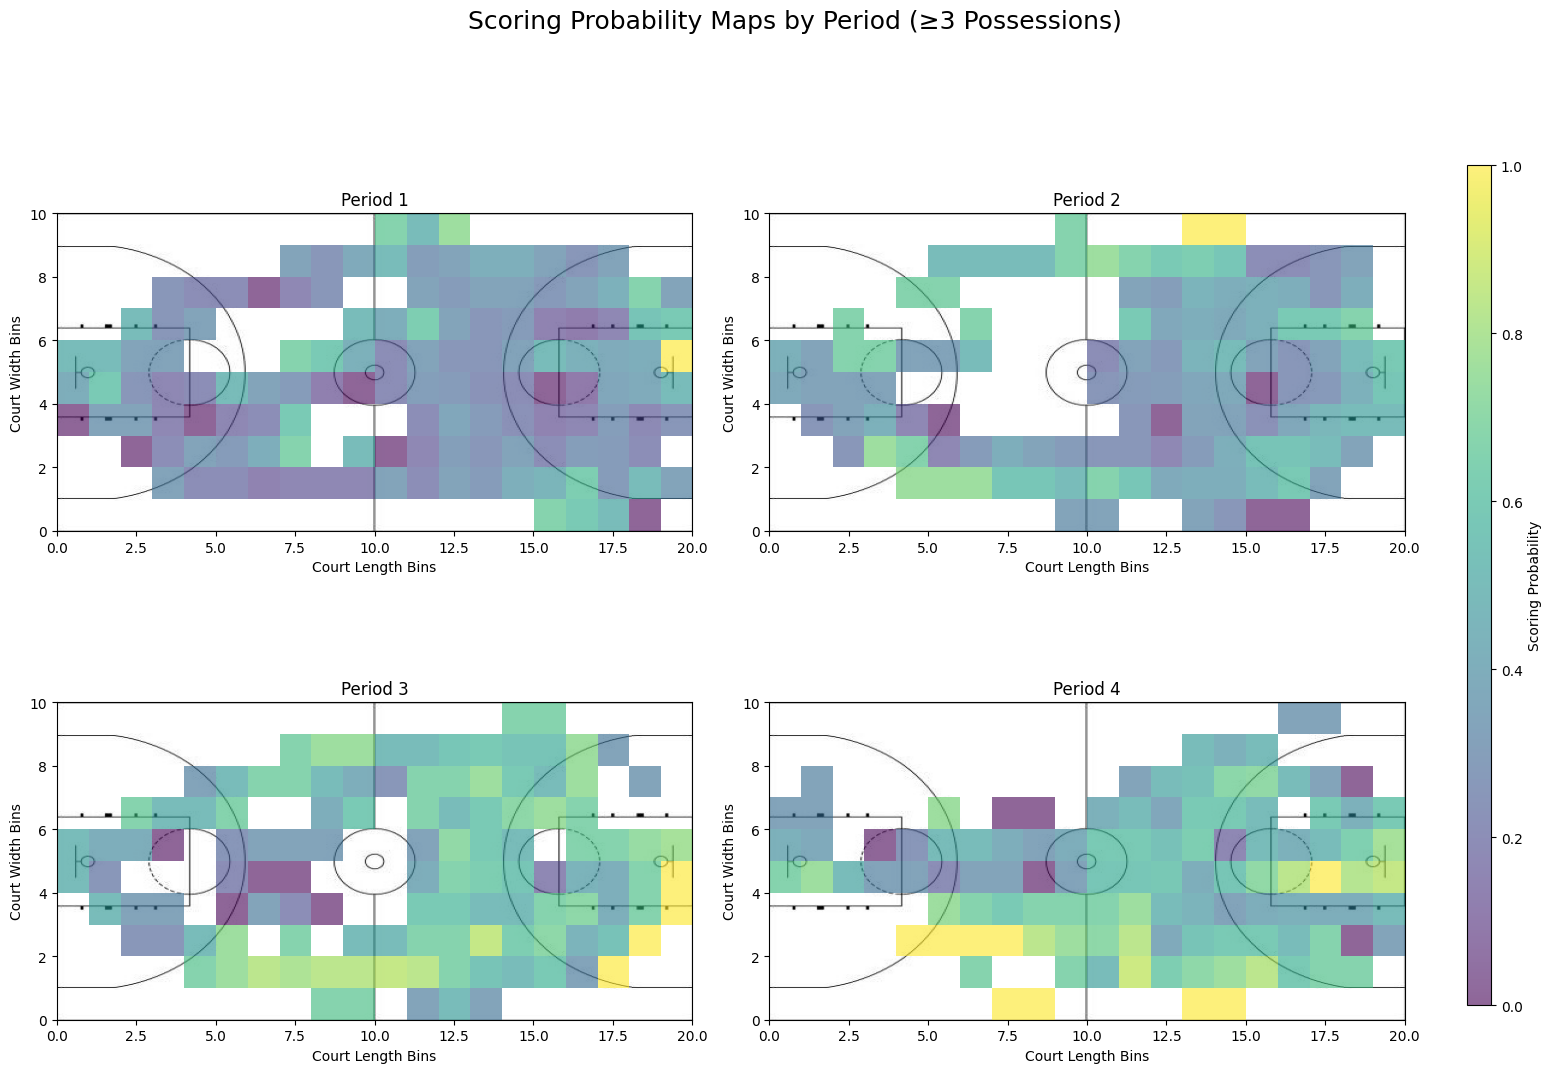

In [49]:
min_visits = 3
x_bins = 20
y_bins = 10
court_img = Image.open("court.jpg")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Scoring Probability Maps by Period (≥{min_visits} Possessions)", fontsize=18)

prob_maps = []

for i, period in enumerate(range(1, 5)):
    ax = axes[i // 2, i % 2]
    subset = last_rows_in_order[
        (last_rows_in_order["z"] < 10) &
        (last_rows_in_order["period"] == period)
    ]

    prob_matrix = calculate_score_probability_matrix_filter_inverted(subset, min_visits, x_bins, y_bins)

    # Skip if matrix is all zeros or NaN
    if np.all(prob_matrix == 0) or np.isnan(prob_matrix).all():
        ax.axis("off")
        continue

    # Plot court and overlay
    ax.imshow(court_img, extent=[0, x_bins, 0, y_bins], aspect='auto')
    overlay = ax.imshow(
        prob_matrix.T,
        cmap='viridis',
        origin='lower',
        extent=[0, x_bins, 0, y_bins],
        alpha=0.6,
        vmin=0, vmax=1
    )

    ax.set_title(f"Period {period}")
    ax.set_xlabel("Court Length Bins")
    ax.set_ylabel("Court Width Bins")
    prob_maps.append(overlay)

# Only show colorbar if at least one heatmap was plotted
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])
if prob_maps:
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(prob_maps[0], cax=cbar_ax, label="Scoring Probability")

plt.show()


## Conclusions Drawn from Naive Analysis and Visualizations

Above we have several plots that show direct movement, ball movement heatmaps per quarter and scoring probability maps. We inverted the heatmaps and probability maps for to interpret all offensive plays as going from left to right.

### Direct Movement

No conclusions can really be drawn from direct movement visualizations. However, this allows to see any errors in the tracking data or any erratic movements. There seems to be some errors within the measurement data, but this could easily be attributed to user error or tracking during timeouts. We combatted this as best as we could while cleaning the data and the results are still good. Overall, the ball movement seems to be in a good and that is shown in these visualizations.

### Ball Movement Heatmaps

The heatmaps give us much more to work with than the direct movement plots, so let's break them down. We set up some filters so we can see movement by `period`, `scored` and some `z` filtering. The first thing we notice is that ball movement appears to be much more erratic during non-scoring plays. This could be due to The Raptors players struggling to find scoring opportunities, forcing them to dribble or pass the ball more often which leads to a less consistent heatmap. Another finding is that we can see the ball was forced above the 3-point line during the first half of the game, indicating difficulty when attempting to drive to the basket or The Raptors were prioritizing 3-point attempts and failing them. Lastly, it appears that attacking on the left side of the basket was more effective, especially in the second half of the game. Their offense may have picked up on something and started to attack that side with a good amount of success. This is also shown in the probability maps that we will discuss next.

### Scoring Probability Maps

Similar to the movement heatmaps, we filtered them by quarter. We also filtered out any sectors that had less than three possesions move through them to handle any over/under representation of scoring in any given sector. Similar to the movement heatmaps, we can see the offensive struggles in the first half, especially in the first quarter. The Raptors were struggling to score early, with a moderate improvement in the second quarter. The second half tells a much different story with an offensive explosion. Both second half quarters show success when moving the ball to the right side of the basket, with solid success driving to the basket in the third quarter. We believe the biggest takeaway here is The Raptors were succesful in the second half, especially while attacking on the right side of the court. The third quarter appears to be the most succesful while attacking the basket when combining raw movement and the probability map, while quarter four shows more attempts at 3-point shooting.



In [50]:
last_rows_in_order.to_csv("Data/analysis_ready.csv")

In [51]:
last_rows_in_order.groupby("possession_number").size().sort_values(ascending=False)
# not many posessions have less than 100 samples
# consider this when bootstrapping

possession_number
64     1276
14      926
39      751
3       626
37      626
       ... 
73      101
72       76
75       76
102      26
103      26
Length: 100, dtype: int64

## Further Possession Cleaning

The below code blocks are to remove any possessions that cross the half court line twice or more. In NBA basketball games, this would be a half-court violation. There is the potential that not all the removed possessions are fouls, but could be an error with tracking, filtering or a plethora of other possible scenarios. Until a new solution is created, these possessions will simply be removed.

In [52]:
# Drop possessions that cross half court twice or more
def count_half_court_crossings(possession_df, half_court_x=47):
    possession_df = possession_df.sort_values("time", ascending=False)
    side = np.sign(possession_df["x"] - half_court_x).replace(0, np.nan).ffill().bfill()
    if side.empty or side.isna().all():
        return 0
    return int(side.ne(side.shift()).sum() - 1)

half_court_crossings_df = (
    last_rows_in_order.groupby("possession_number")
    .apply(count_half_court_crossings)
    .rename("half_court_crossings")
    .reset_index()
)

possessions_to_drop = half_court_crossings_df.loc[
    half_court_crossings_df["half_court_crossings"] >= 2,
    "possession_number",
]

dropped_half_court_crossers_df = last_rows_in_order[
    last_rows_in_order["possession_number"].isin(possessions_to_drop)
].merge(half_court_crossings_df, on="possession_number", how="left")

last_rows_half_court_filtered = last_rows_in_order[
    ~last_rows_in_order["possession_number"].isin(possessions_to_drop)
].merge(half_court_crossings_df, on="possession_number", how="left")

print(f"Possessions before half-court filter: {last_rows_in_order['possession_number'].nunique()}")
print(f"Dropped possessions crossing half court twice or more: {len(possessions_to_drop)}")
print(f"Possessions after half-court filter: {last_rows_half_court_filtered['possession_number'].nunique()}")

display(last_rows_half_court_filtered)
display(dropped_half_court_crossers_df)

last_rows_half_court_filtered.to_csv("Data/analysis_ready_half_court_filtered.csv", index=False)


Possessions before half-court filter: 100
Dropped possessions crossing half court twice or more: 9
Possessions after half-court filter: 91


,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored,movement_eligible,zero_duration,x_bin,y_bin,half_court_crossings
0,1,719.00,37.04728,15.02163,6.44393,720.0,703,1,1,1,2,1,True,False,7,3,1
1,1,718.96,36.30142,14.70948,6.12091,720.0,703,1,1,1,2,1,True,False,7,2,1
2,1,718.92,35.67854,14.33637,5.70189,720.0,703,1,1,1,2,1,True,False,7,2,1
3,1,718.88,34.84530,13.68251,5.15255,720.0,703,1,1,1,2,1,True,False,7,2,1
4,1,718.84,34.18749,13.55080,4.64143,720.0,703,1,1,1,2,1,True,False,7,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33608,4,12.16,66.14200,21.61843,4.11262,13.0,12,204,103,103,1,1,True,False,14,4,0
33609,4,12.12,66.17081,21.87346,4.15078,13.0,12,204,103,103,1,1,True,False,14,4,0
33610,4,12.08,66.19728,22.08677,4.19980,13.0,12,204,103,103,1,1,True,False,14,4,0
33611,4,12.04,66.21909,22.24976,4.26088,13.0,12,204,103,103,1,1,True,False,14,4,0


,period,time,x,y,z,possession_start,possession_end,source_row_number,SOURCE_POSSESSION_NUMBER,possession_number,points_scored,scored,movement_eligible,zero_duration,x_bin,y_bin,half_court_crossings
0,1,484.00,34.27966,20.74682,3.41847,484.0,463,21,11,11,0,0,True,False,7,4,2
1,1,483.96,34.44427,20.79422,3.44758,484.0,463,21,11,11,0,0,True,False,7,4,2
2,1,483.92,34.86374,20.66221,3.90889,484.0,463,21,11,11,0,0,True,False,7,4,2
3,1,483.88,35.09255,20.78869,3.99875,484.0,463,21,11,11,0,0,True,False,7,4,2
4,1,483.84,35.29932,20.83709,4.02497,484.0,463,21,11,11,0,0,True,False,7,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4554,4,118.16,54.47716,44.80856,2.34198,138.0,118,192,97,97,2,1,True,False,11,8,2
4555,4,118.12,55.38341,45.04657,1.88036,138.0,118,192,97,97,2,1,True,False,11,9,2
4556,4,118.08,56.20604,45.25208,1.46342,138.0,118,192,97,97,2,1,True,False,11,9,2
4557,4,118.04,56.95073,45.45975,1.16161,138.0,118,192,97,97,2,1,True,False,12,9,2


In [53]:
dropped_half_court_crossers_df.groupby("possession_number")["scored"].first()
# 7 non-scoring, 2 scoring possessions

possession_number
11    0
20    0
30    0
33    0
37    0
58    0
61    0
93    1
97    1
Name: scored, dtype: int64